# Post-Hoc Reasoning Results Visualization

This notebook creates visualizations for parse rates and steering success rates across different alpha values.

In [219]:
import os
import json
import pickle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import defaultdict
import pandas as pd

# Set style for cleaner plots
plt.style.use('default')  # Reset to default first
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['axes.edgecolor'] = '#CCCCCC'
plt.rcParams['axes.linewidth'] = 1.0
plt.rcParams['grid.color'] = '#EEEEEE'
plt.rcParams['grid.linestyle'] = '-'
plt.rcParams['grid.linewidth'] = 0.8

# Use clean system fonts that are widely available
# These fonts are similar to Lato (clean, modern sans-serif)
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = [
    'Helvetica Neue',      # macOS (very clean, similar to Lato)
    'Arial',               # Windows/Mac/Linux (clean and widely available)
    'Liberation Sans',     # Linux (open source, clean design)
    'DejaVu Sans',        # Cross-platform (matplotlib default)
    'sans-serif'          # Generic fallback
]

# Optional: Use a slightly lighter font weight if available
plt.rcParams['font.weight'] = 'normal'

In [220]:
# Configuration
CACHE_DIR = Path("new_cache/experiments")
MODELS = [
    "google/gemma-2-2b-it",
    "google/gemma-2-9b-it", 
    "Qwen/Qwen2.5-3B-Instruct",
    "Qwen/Qwen2.5-7B-Instruct",
    "microsoft/Phi-3-small-8k-instruct",
    "meta-llama/Llama-2-7b-chat-hf",
    "deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B",
    "deepseek-ai/DeepSeek-R1-Distill-Qwen-7B"
]
DATASETS = ["anachronisms", "logical_deduction", "social_chemistry", "sports_understanding"]

In [ ]:
def load_steering_results(model_path, dataset):
    """Load all steering results for a given model and dataset."""
    results = defaultdict(list)
    
    # Try both cache directories
    for cache_name in ["cache/experiments", "new_cache/experiments"]:
        cache_dir = Path(cache_name)
        if not cache_dir.exists():
            continue
            
        # Find the experiment directory
        model_dir = cache_dir / model_path.replace("/", "_") / dataset
        if not model_dir.exists():
            # Try without underscores in model name
            model_dir = cache_dir / model_path.replace("/", "-") / dataset
            if not model_dir.exists():
                continue
        
        # Find the split directory (assuming first one found)
        split_dirs = list(model_dir.glob("split_*"))
        if not split_dirs:
            continue
        
        split_dir = split_dirs[0]
        
        # Find the hash directory
        hash_dirs = [d for d in split_dir.iterdir() if d.is_dir() and len(d.name) > 10]
        if not hash_dirs:
            continue
        
        hash_dir = hash_dirs[0]
        steering_dir = hash_dir / "steering"
        
        if not steering_dir.exists():
            continue
        
        # Load all steering result files
        for file_path in steering_dir.glob("*.pkl"):
            # Parse filename to get alpha and direction
            filename = file_path.stem
            parts = filename.split("_")
            
            if "alpha" in filename:
                # Find alpha value
                alpha_idx = parts.index("alpha") + 1
                alpha = float(parts[alpha_idx])
                
                # For alpha=0, the suffix indicates the ORIGINAL answer
                # We need to assign to the OPPOSITE direction (the steering target)
                if alpha == 0:
                    if "yes" in filename:
                        # Original answer is yes, so this is yes→no steering
                        direction = "no"  # FIXED: was "yes"
                    elif "no" in filename:
                        # Original answer is no, so this is no→yes steering
                        direction = "yes"  # FIXED: was "no"
                    else:
                        continue  # Skip if direction unclear
                else:
                    # For non-zero alpha, determine by sign
                    # Positive alpha = no→yes steering (direction = "yes")
                    # Negative alpha = yes→no steering (direction = "no")
                    direction = "yes" if alpha > 0 else "no"
                
                # Load the results
                with open(file_path, "rb") as f:
                    data = pickle.load(f)
                    results[direction].append((abs(alpha), data))
        
        # If we found results, break (don't check other cache)
        if results:
            break
    
    return results

In [222]:
def calculate_metrics(steering_data):
    """Calculate no parse rate and steering success rate from steering results with confidence intervals."""
    if not steering_data:
        return 0.0, 0.0, 0.0, 0.0
    
    total = len(steering_data)
    valid_parses = sum(1 for item in steering_data if item.get('is_valid_parse', False))
    successes = sum(1 for item in steering_data if item.get('success', False))
    
    # No parse rate is 1 - parse rate
    no_parse_rate = 1 - (valid_parses / total) if total > 0 else 0.0
    # Success rate denominator is number of valid parses, not total
    success_rate = successes / valid_parses if valid_parses > 0 else 0.0
    
    # Calculate standard errors using binomial proportion formula
    # SE = sqrt(p * (1-p) / n)
    no_parse_se = np.sqrt(no_parse_rate * (1 - no_parse_rate) / total) if total > 0 else 0.0
    success_se = np.sqrt(success_rate * (1 - success_rate) / valid_parses) if valid_parses > 0 else 0.0
    
    # Convert to 95% confidence interval (1.96 * SE)
    no_parse_ci = 1.96 * no_parse_se
    success_ci = 1.96 * success_se
    
    # Ensure confidence intervals don't go below 0 or above 1
    # This is especially important for extreme rates near 0 or 1
    # The CI returned here is the half-width that will be added/subtracted from the rate
    # So we need to ensure rate - CI >= 0 and rate + CI <= 1
    success_ci = min(success_ci, success_rate, 1 - success_rate)
    no_parse_ci = min(no_parse_ci, no_parse_rate, 1 - no_parse_rate)
    
    return no_parse_rate, success_rate, no_parse_ci, success_ci

In [223]:
def create_bar_plots(model, dataset, direction_data, direction="yes"):
    """Create bar plots for steering success rate with no parse rate as a line."""
    if not direction_data:
        return None
    
    # Sort by alpha value
    direction_data.sort(key=lambda x: x[0])
    
    alphas = []
    no_parse_rates = []
    success_rates = []
    no_parse_errors = []
    success_errors = []
    
    for alpha, data in direction_data:
        no_parse_rate, success_rate, no_parse_ci, success_ci = calculate_metrics(data)
        alphas.append(alpha)
        no_parse_rates.append(no_parse_rate)
        success_rates.append(success_rate)
        no_parse_errors.append(no_parse_ci)
        success_errors.append(success_ci)
    
    # Create figure with white background
    fig, ax = plt.subplots(figsize=(10, 7))
    fig.patch.set_facecolor('white')
    ax.set_facecolor('white')
    
    # Bar positions
    x = np.arange(len(alphas))
    width = 0.8  # Make bars wider so they touch
    
    # Create bars for success rate with specified blue color (122, 173, 169) = #7AADA9
    bars = ax.bar(x, success_rates, width, 
                   yerr=success_errors, capsize=0,  # No caps on error bars
                   color='#7AADA9', alpha=0.9,  # Almost opaque (0.1 transparency)
                   edgecolor='#7AADA9', linewidth=1.5,
                   error_kw={'linewidth': 1.5, 'elinewidth': 1.5, 'color': '#808080'})  # Grey error bars
    
    # Add no parse rate as a dashed line with specified red (201, 88, 83) = #C95853
    line = ax.plot(x, no_parse_rates, '--', color='#C95853', linewidth=1.8,  # Using RGB(201, 88, 83)
                   marker='o', markersize=4, markerfacecolor='#C95853',  # Smaller dots filled with red
                   markeredgewidth=0, markeredgecolor='#C95853',
                   label='Failed Parse Rate', zorder=10)
    
    # Customize plot with regular font weight and black color
    ax.set_xlabel('α', fontsize=14, fontweight='normal', color='black')  # Changed to alpha symbol
    ax.set_ylabel('Rate', fontsize=14, fontweight='normal', color='black')
    
    # Format model name (take part after slash, replace dashes with spaces)
    model_display = model.split('/')[-1].replace('-', ' ')
    
    # Format dataset name (replace underscores with spaces)
    dataset_display = dataset.replace('_', ' ')
    
    # Format title with regular weight and black color
    ax.set_title(f'{model_display}\n{dataset_display}: {direction}', 
                 fontsize=16, fontweight='normal', color='black', pad=20)
    
    ax.set_xticks(x)
    ax.set_xticklabels([str(int(a)) if a.is_integer() else str(a) for a in alphas], 
                       fontsize=12, color='black')
    
    # Create custom legend - smaller and in top left
    from matplotlib.patches import Patch
    from matplotlib.lines import Line2D
    legend_elements = [
        Patch(facecolor='#7AADA9', edgecolor='#7AADA9', alpha=0.9, label='Steering Success Rate'),
        Line2D([0], [0], color='#C95853', linewidth=1.8, linestyle='--', 
               marker='o', markersize=4, markerfacecolor='#C95853', 
               markeredgewidth=0, markeredgecolor='#C95853', label='Failed Parse Rate')
    ]
    ax.legend(handles=legend_elements, loc='upper left', frameon=False,  # Top left, no frame
              fontsize=9, handlelength=1.5, handletextpad=0.5)  # Even smaller font and spacing
    
    # Set y-axis limits and ticks
    ax.set_ylim(-0.05, 1.05)
    ax.set_yticks(np.arange(0, 1.1, 0.2))
    ax.set_yticklabels([f'{y:.1f}' for y in np.arange(0, 1.1, 0.2)], 
                       fontsize=12, color='black')
    
    # Add dotted grey grid, slightly more visible
    ax.grid(True, axis='y', alpha=0.5, linestyle=':', linewidth=1.0, color='#808080')
    ax.set_axisbelow(True)
    
    # Remove all value labels (both for bars and line)
    # No labels on bars anymore
    # No labels on the red line anymore
    
    # Remove top and right spines for cleaner look
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Make remaining spines lighter
    ax.spines['bottom'].set_color('#CCCCCC')
    ax.spines['left'].set_color('#CCCCCC')
    
    plt.tight_layout()
    return fig


Processing google/gemma-2-2b-it - anachronisms...


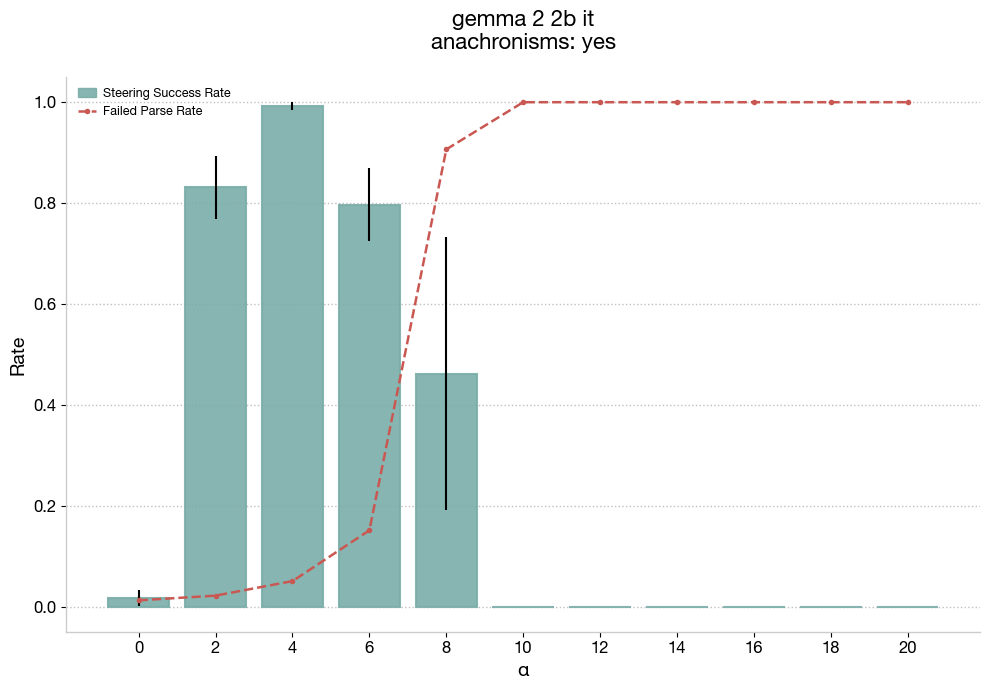

  Created yes direction plot


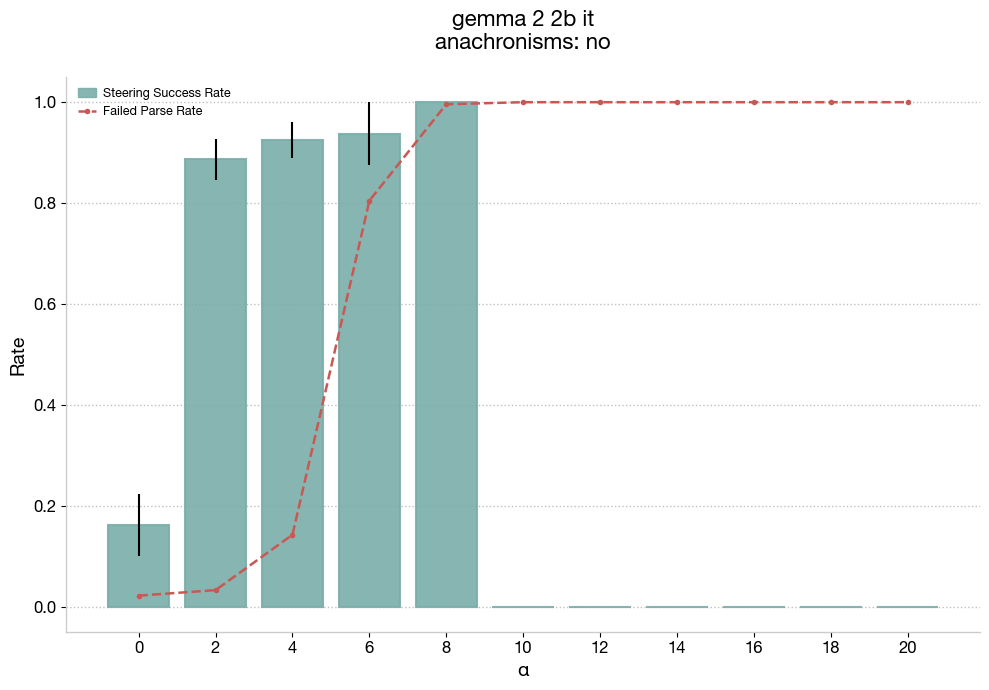

  Created no direction plot

Processing google/gemma-2-2b-it - logical_deduction...
  No steering results found

Processing google/gemma-2-2b-it - social_chemistry...
  No steering results found

Processing google/gemma-2-2b-it - sports_understanding...


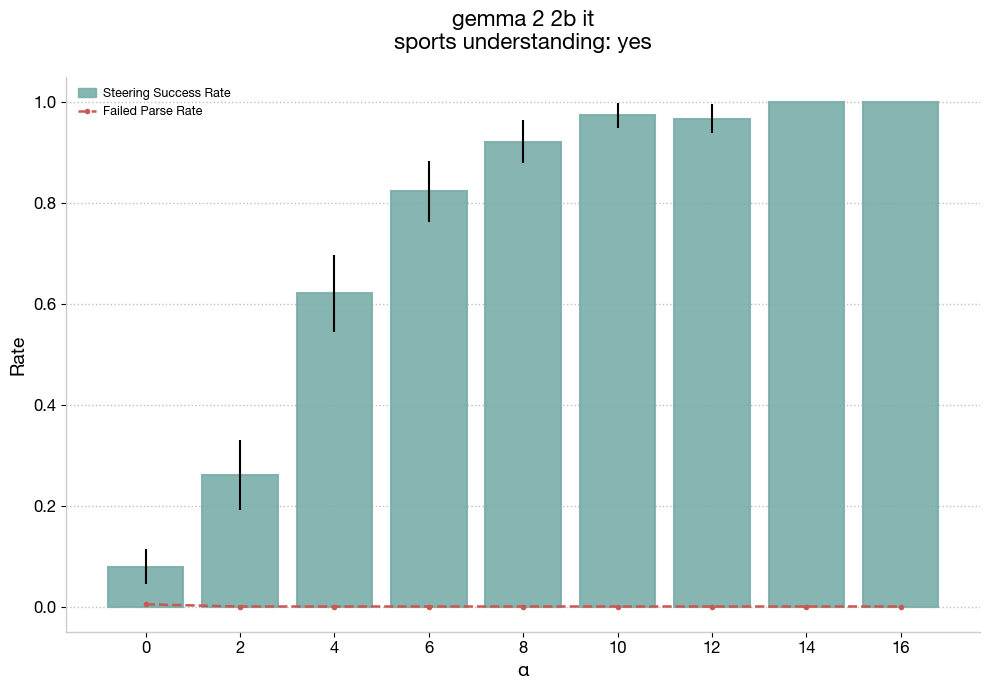

  Created yes direction plot


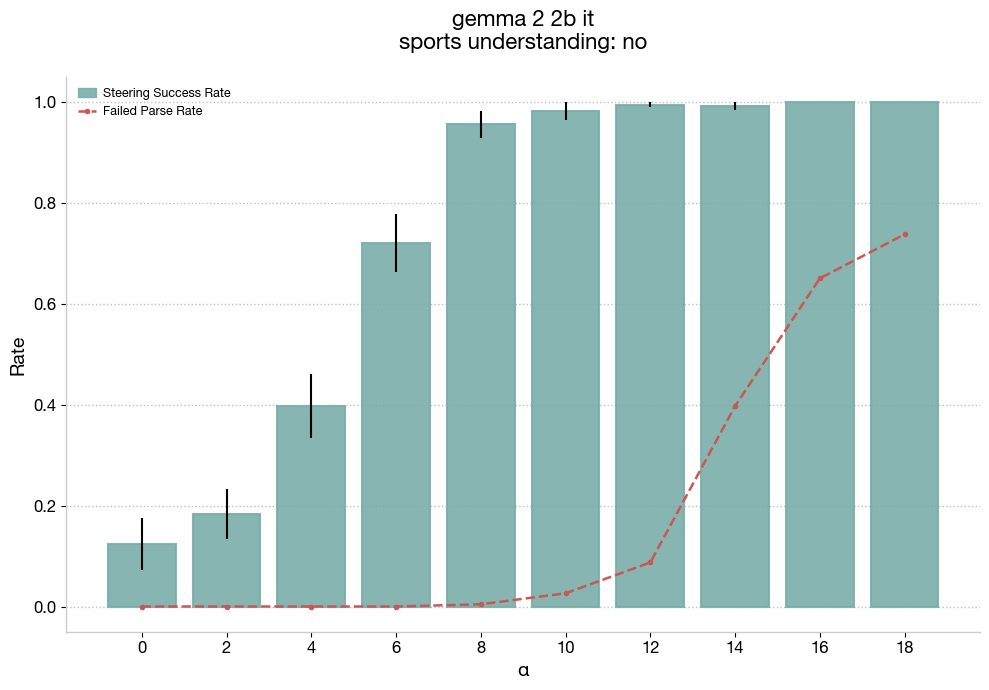

  Created no direction plot

Processing google/gemma-2-9b-it - anachronisms...
  No steering results found

Processing google/gemma-2-9b-it - logical_deduction...
  No steering results found

Processing google/gemma-2-9b-it - social_chemistry...
  No steering results found

Processing google/gemma-2-9b-it - sports_understanding...


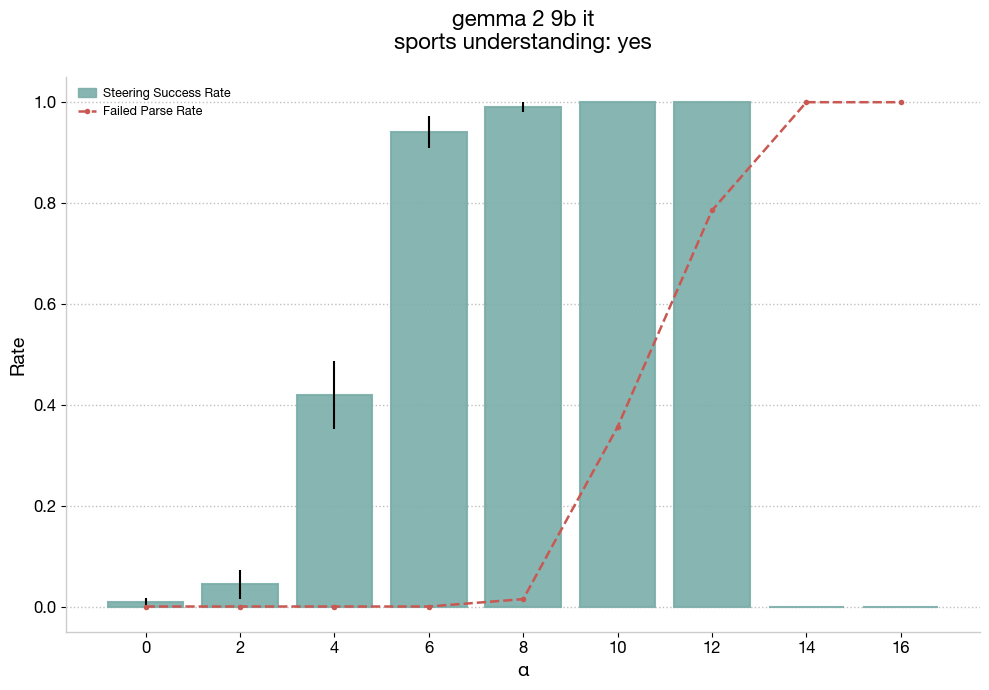

  Created yes direction plot


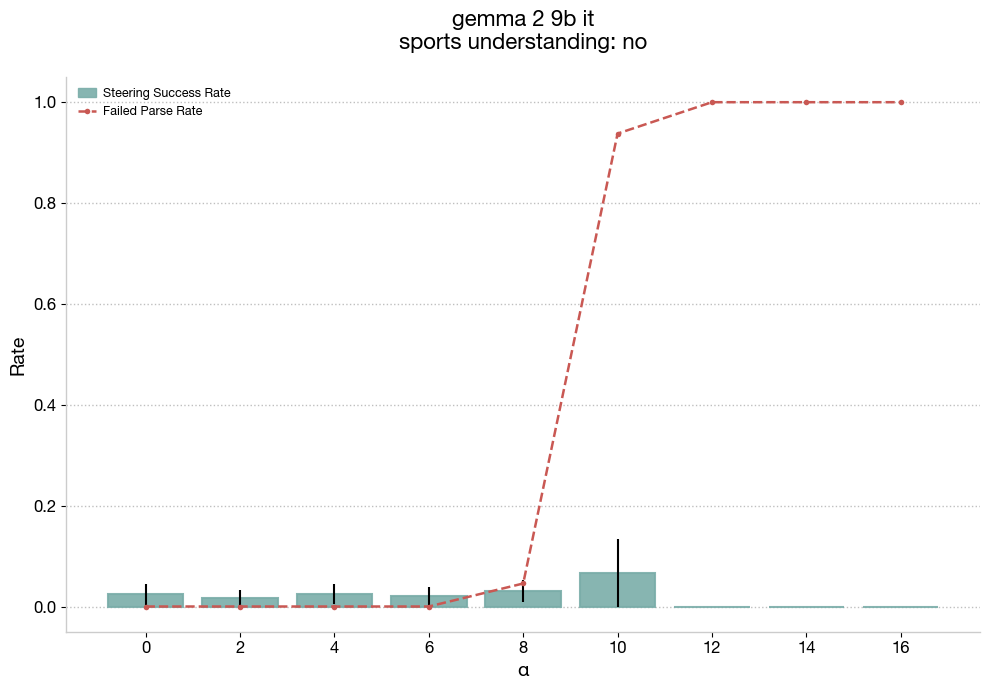

  Created no direction plot

Processing Qwen/Qwen2.5-3B-Instruct - anachronisms...
  No steering results found

Processing Qwen/Qwen2.5-3B-Instruct - logical_deduction...


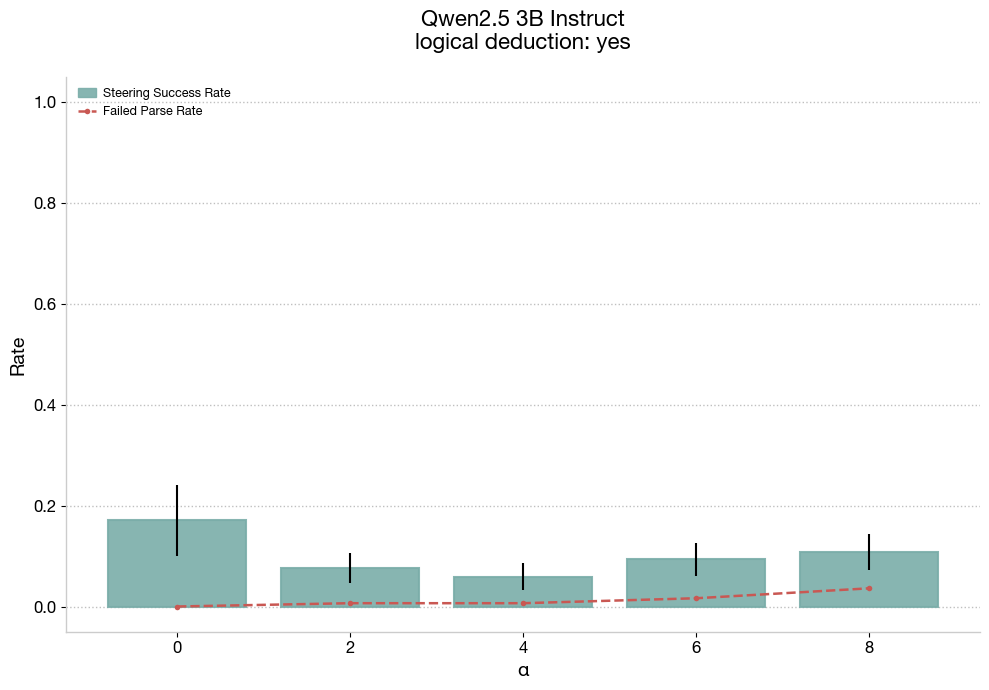

  Created yes direction plot


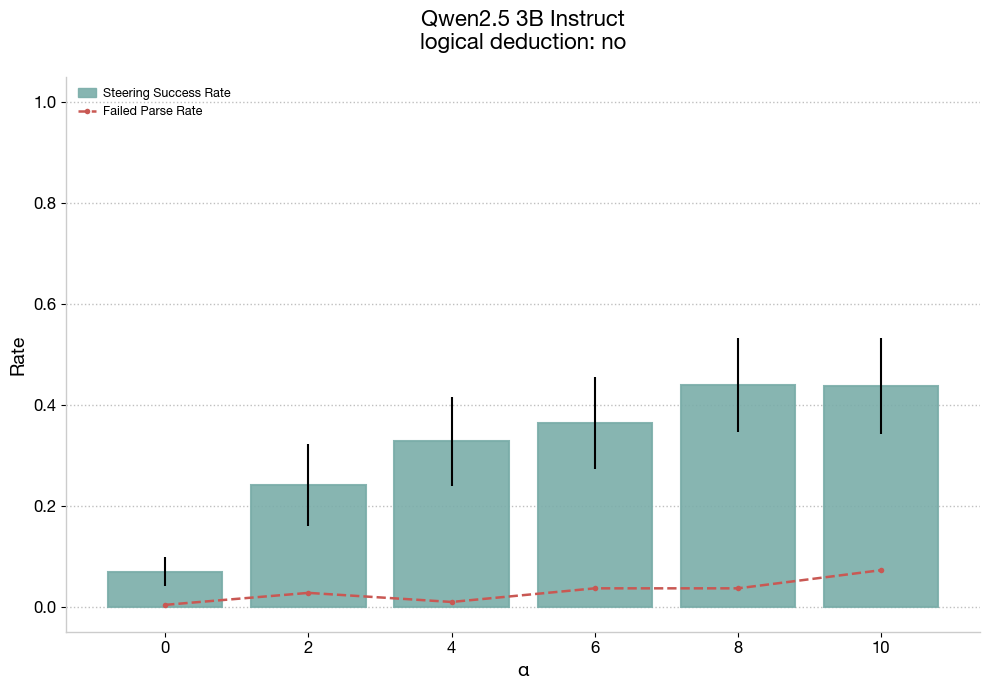

  Created no direction plot

Processing Qwen/Qwen2.5-3B-Instruct - social_chemistry...
  No steering results found

Processing Qwen/Qwen2.5-3B-Instruct - sports_understanding...


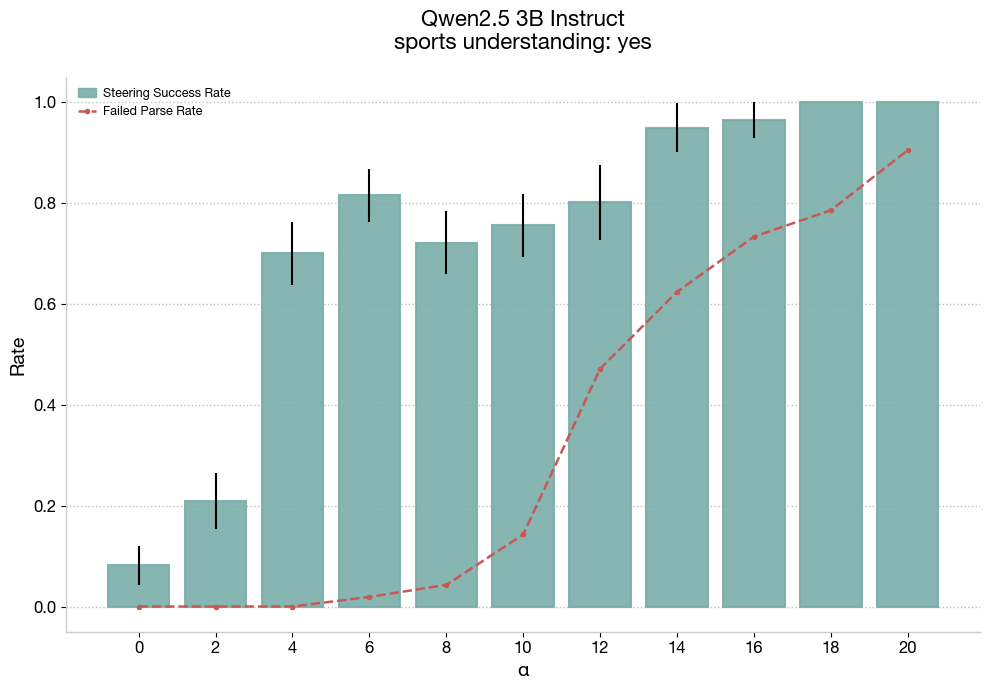

  Created yes direction plot


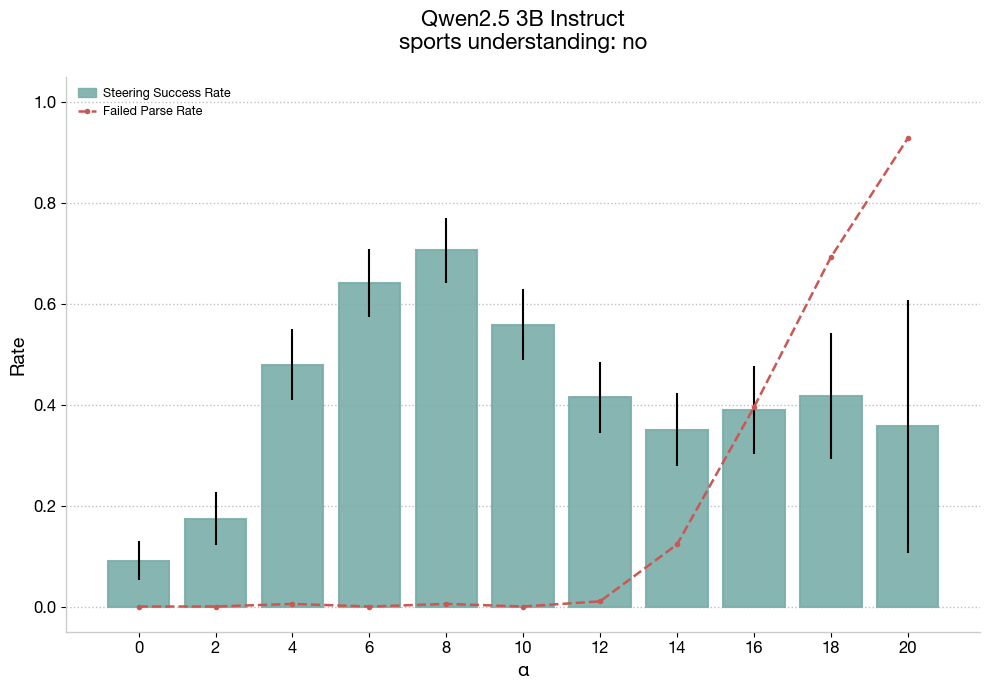

  Created no direction plot

Processing Qwen/Qwen2.5-7B-Instruct - anachronisms...


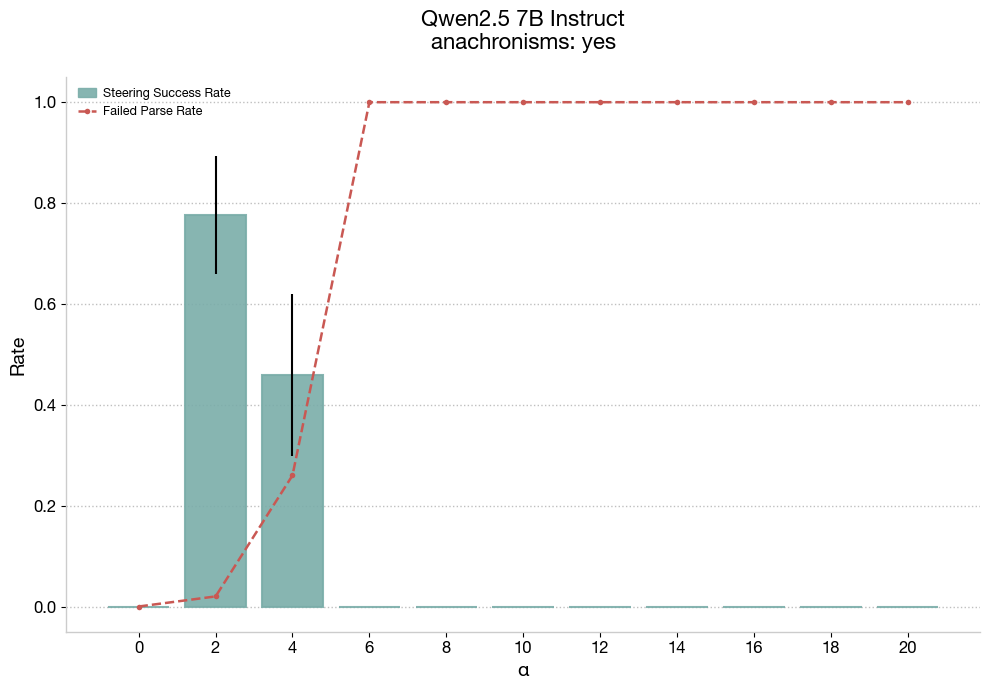

  Created yes direction plot


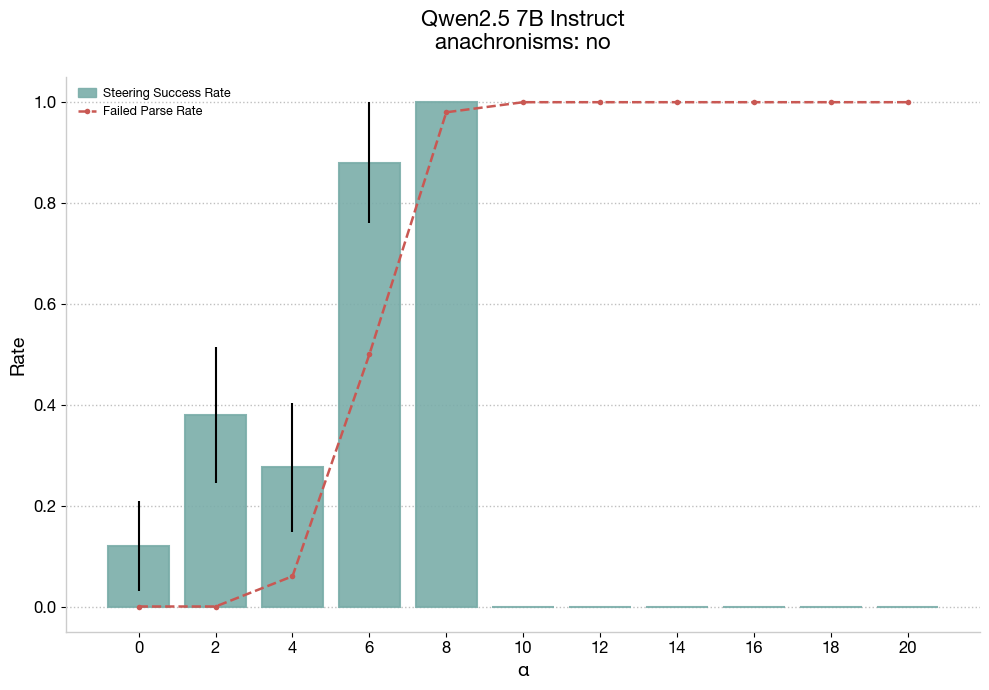

  Created no direction plot

Processing Qwen/Qwen2.5-7B-Instruct - logical_deduction...


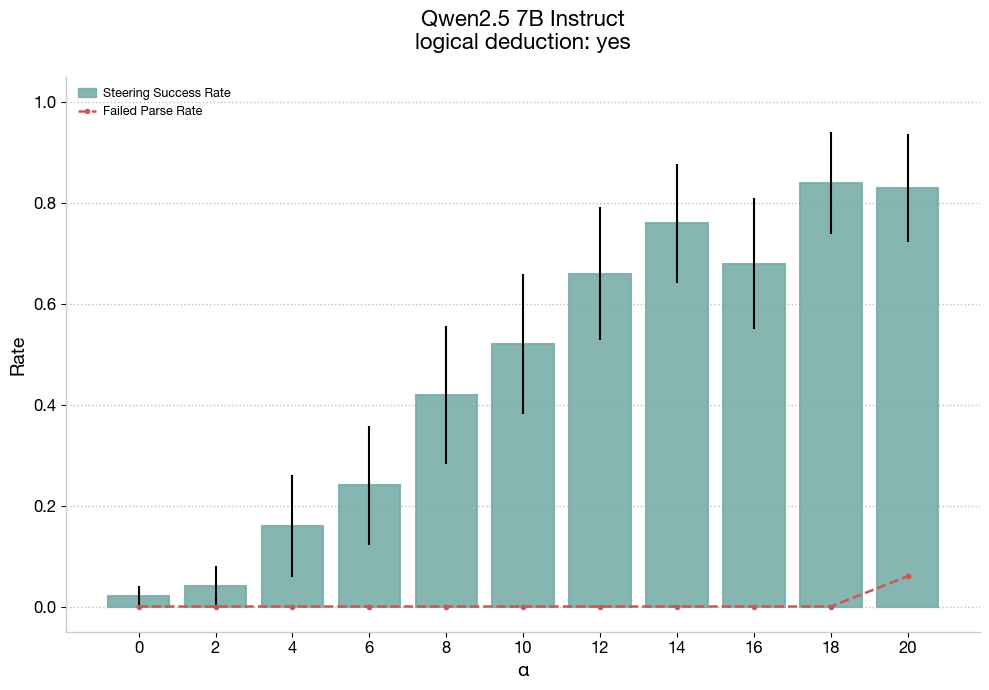

  Created yes direction plot


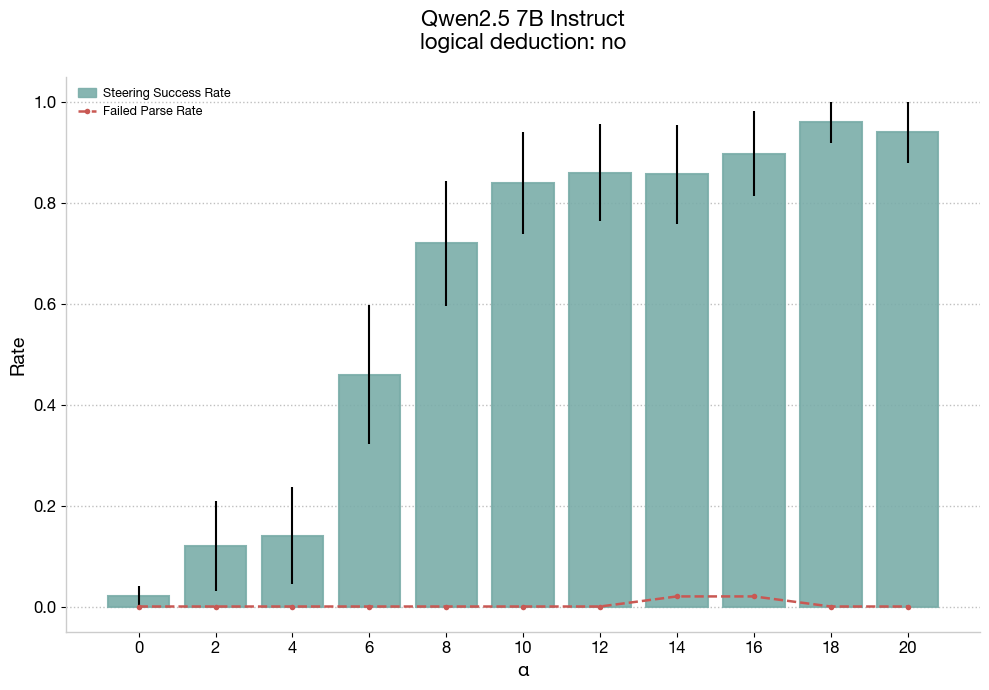

  Created no direction plot

Processing Qwen/Qwen2.5-7B-Instruct - social_chemistry...


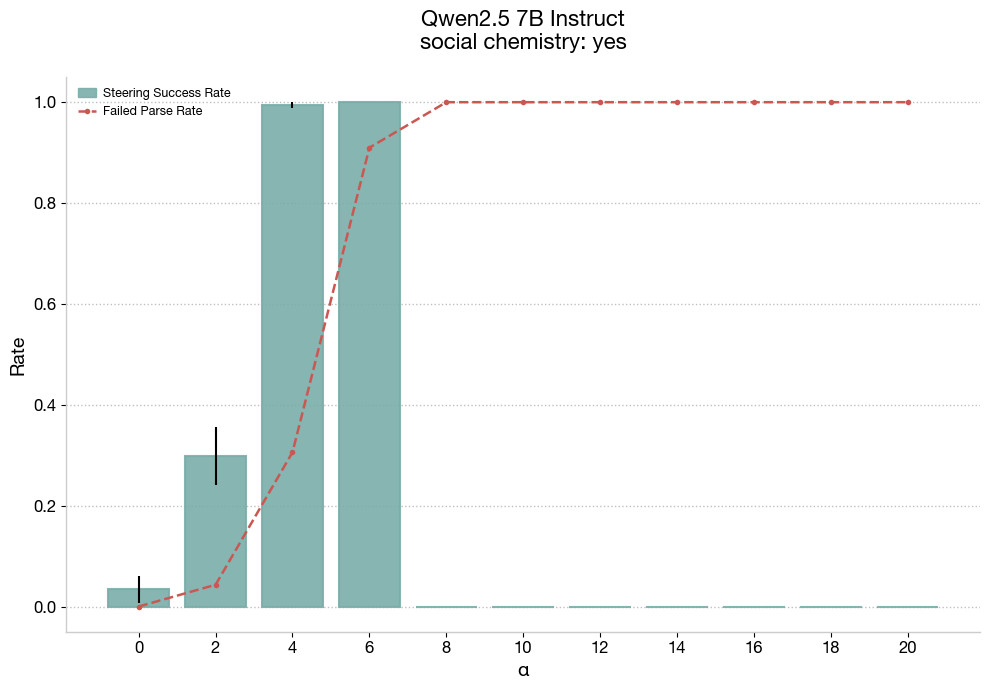

  Created yes direction plot


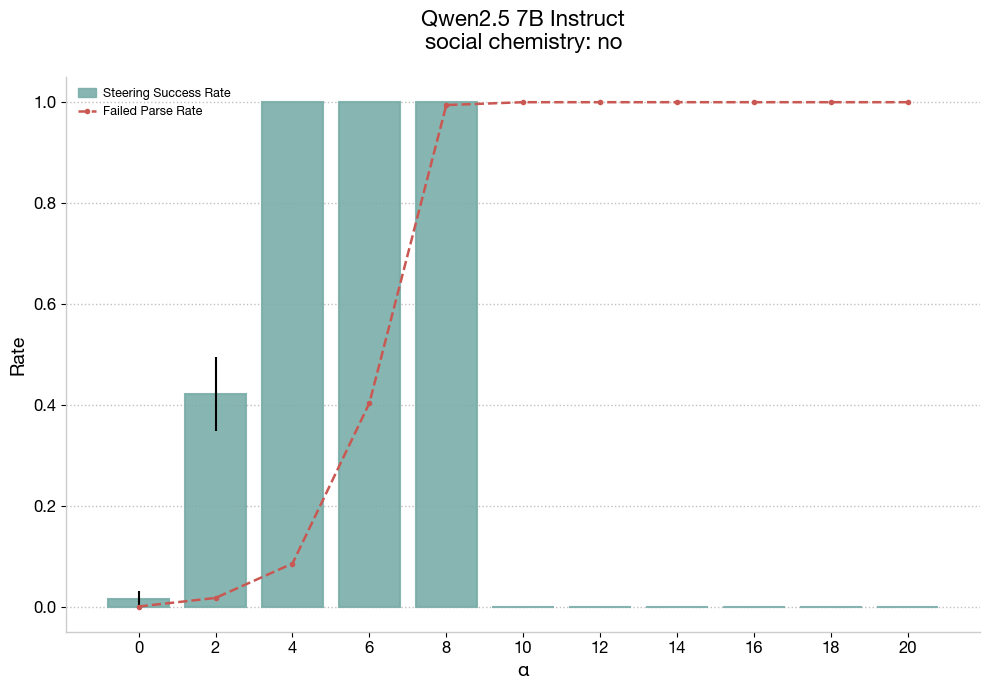

  Created no direction plot

Processing Qwen/Qwen2.5-7B-Instruct - sports_understanding...


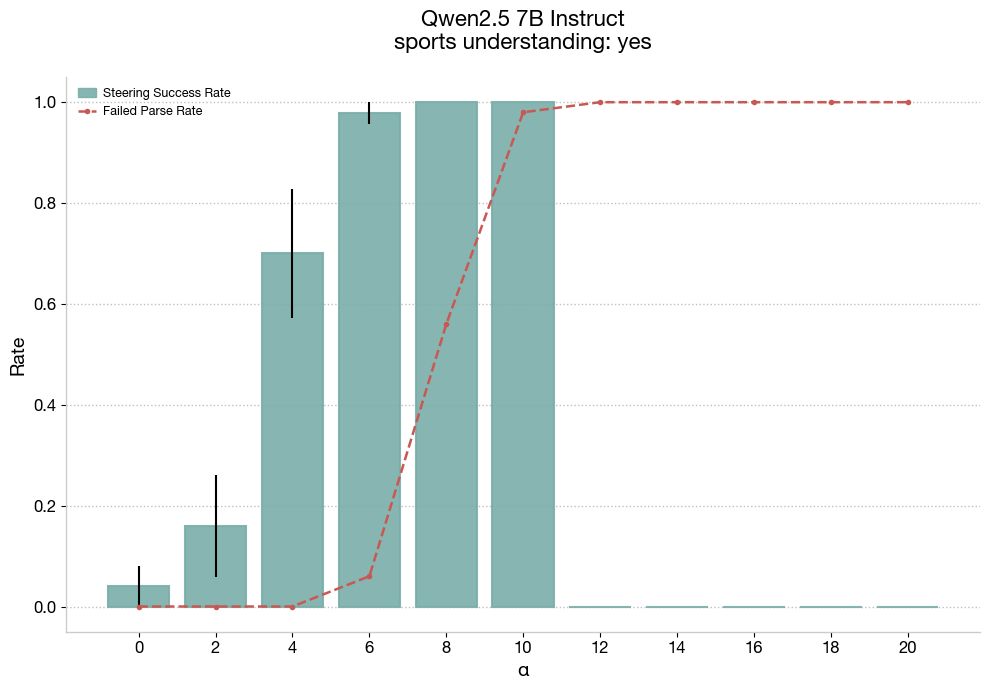

  Created yes direction plot


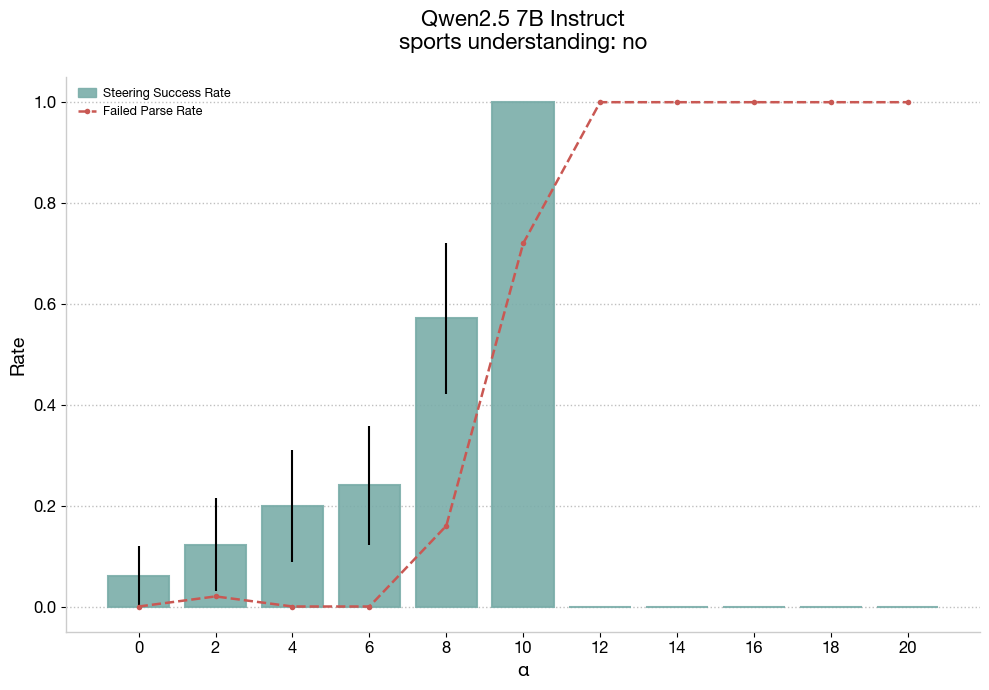

  Created no direction plot

Processing microsoft/Phi-3-small-8k-instruct - anachronisms...
  No steering results found

Processing microsoft/Phi-3-small-8k-instruct - logical_deduction...
  No steering results found

Processing microsoft/Phi-3-small-8k-instruct - social_chemistry...
  No steering results found

Processing microsoft/Phi-3-small-8k-instruct - sports_understanding...
  No steering results found

Processing meta-llama/Llama-2-7b-chat-hf - anachronisms...
  No steering results found

Processing meta-llama/Llama-2-7b-chat-hf - logical_deduction...
  No steering results found

Processing meta-llama/Llama-2-7b-chat-hf - social_chemistry...
  No steering results found

Processing meta-llama/Llama-2-7b-chat-hf - sports_understanding...
  No steering results found

Processing deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B - anachronisms...
  No steering results found

Processing deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B - logical_deduction...
  No steering results found

Processing d

In [224]:
# Generate visualizations for all model-dataset combinations
all_figures = []

for model in MODELS:
    for dataset in DATASETS:
        print(f"\nProcessing {model} - {dataset}...")
        
        # Load steering results
        results = load_steering_results(model, dataset)
        
        if not results:
            print(f"  No steering results found")
            continue
        
        # Create plots for both directions
        for direction in ["yes", "no"]:
            if direction in results:
                fig = create_bar_plots(model, dataset, results[direction], direction)
                if fig:
                    all_figures.append((model, dataset, direction, fig))
                    plt.show()
                    print(f"  Created {direction} direction plot")
            else:
                print(f"  No {direction} direction data found")

In [225]:
# Save all figures to files
output_dir = Path("visualizations")
output_dir.mkdir(exist_ok=True)

for model, dataset, direction, fig in all_figures:
    filename = f"{model.replace('/', '_')}_{dataset}_{direction}.png"
    filepath = output_dir / filename
    fig.savefig(filepath, dpi=300, bbox_inches='tight')
    print(f"Saved: {filepath}")

Saved: visualizations/google_gemma-2-2b-it_anachronisms_yes.png
Saved: visualizations/google_gemma-2-2b-it_anachronisms_no.png
Saved: visualizations/google_gemma-2-2b-it_sports_understanding_yes.png
Saved: visualizations/google_gemma-2-2b-it_sports_understanding_no.png
Saved: visualizations/google_gemma-2-9b-it_sports_understanding_yes.png
Saved: visualizations/google_gemma-2-9b-it_sports_understanding_no.png
Saved: visualizations/Qwen_Qwen2.5-3B-Instruct_logical_deduction_yes.png
Saved: visualizations/Qwen_Qwen2.5-3B-Instruct_logical_deduction_no.png
Saved: visualizations/Qwen_Qwen2.5-3B-Instruct_sports_understanding_yes.png
Saved: visualizations/Qwen_Qwen2.5-3B-Instruct_sports_understanding_no.png
Saved: visualizations/Qwen_Qwen2.5-7B-Instruct_anachronisms_yes.png
Saved: visualizations/Qwen_Qwen2.5-7B-Instruct_anachronisms_no.png
Saved: visualizations/Qwen_Qwen2.5-7B-Instruct_logical_deduction_yes.png
Saved: visualizations/Qwen_Qwen2.5-7B-Instruct_logical_deduction_no.png
Saved: visu

In [242]:
# Create summary statistics
summary_data = []

for model in MODELS:
    for dataset in DATASETS:
        results = load_steering_results(model, dataset)
        
        if results:
            for direction in ["yes", "no"]:
                if direction in results:
                    for alpha, data in results[direction]:
                        no_parse_rate, success_rate, no_parse_ci, success_ci = calculate_metrics(data)
                        summary_data.append({
                            'Model': model.split('/')[-1],
                            'Dataset': dataset,
                            'Direction': direction,
                            'Alpha': alpha,
                            'No Parse Rate': no_parse_rate,
                            'Success Rate': success_rate,
                            'No Parse CI': no_parse_ci,
                            'Success CI': success_ci,
                            'N': len(data)
                        })

# Create DataFrame and display summary
if summary_data:
    df = pd.DataFrame(summary_data)
    print("\nSummary Statistics:")
    print(df.head(50))
    # print(df.groupby(['Model', 'Dataset', 'Direction'])[['No Parse Rate', 'Success Rate']].agg(['mean', 'std', 'max']))


Summary Statistics:
            Model               Dataset Direction  Alpha  No Parse Rate  \
0   gemma-2-2b-it          anachronisms       yes   20.0       1.000000   
1   gemma-2-2b-it          anachronisms       yes   16.0       1.000000   
2   gemma-2-2b-it          anachronisms       yes   18.0       1.000000   
3   gemma-2-2b-it          anachronisms       yes    2.0       0.021583   
4   gemma-2-2b-it          anachronisms       yes   14.0       1.000000   
5   gemma-2-2b-it          anachronisms       yes   10.0       1.000000   
6   gemma-2-2b-it          anachronisms       yes    6.0       0.151079   
7   gemma-2-2b-it          anachronisms       yes    4.0       0.050360   
8   gemma-2-2b-it          anachronisms       yes    0.0       0.012195   
9   gemma-2-2b-it          anachronisms       yes   12.0       1.000000   
10  gemma-2-2b-it          anachronisms       yes    8.0       0.906475   
11  gemma-2-2b-it          anachronisms        no   18.0       1.000000   
12  

# Probe AUC Visualization Section

In [227]:
def load_auc_scores(model_path, dataset):
    """Load AUC scores for a given model and dataset."""
    # Find the experiment directory
    model_dir = CACHE_DIR / model_path.replace("/", "_") / dataset
    if not model_dir.exists():
        return None
    
    # Find the split directory
    split_dirs = list(model_dir.glob("split_*"))
    if not split_dirs:
        return None
    
    split_dir = split_dirs[0]
    
    # Find the hash directory
    hash_dirs = [d for d in split_dir.iterdir() if d.is_dir() and d.name not in ["data", "metadata", "probes", "steering"]]
    if not hash_dirs:
        return None
    
    hash_dir = hash_dirs[0]
    auc_file = hash_dir / "probes" / "auc_scores.json"
    
    if not auc_file.exists():
        return None
    
    with open(auc_file, "r") as f:
        return json.load(f)

In [228]:
def load_generation_accuracy(model_path, dataset):
    """Load generation data and calculate train/test accuracy."""
    accuracies = {'train': None, 'test': None}
    
    # Try both cache directories
    for cache_name in ["cache/experiments", "new_cache/experiments"]:
        cache_dir = Path(cache_name)
        if not cache_dir.exists():
            continue
            
        # Find the experiment directory
        model_dir = cache_dir / model_path.replace("/", "_") / dataset
        if not model_dir.exists():
            # Try without underscores in model name
            model_dir = cache_dir / model_path.replace("/", "-") / dataset
            if not model_dir.exists():
                continue
        
        # Find the split directory
        split_dirs = list(model_dir.glob("split_*"))
        if not split_dirs:
            continue
        
        split_dir = split_dirs[0]
        
        # Find the hash directory
        hash_dirs = [d for d in split_dir.iterdir() if d.is_dir() and len(d.name) > 10]
        if not hash_dirs:
            continue
        
        hash_dir = hash_dirs[0]
        data_dir = hash_dir / "data"
        
        # Load train and test generations
        for split in ['train', 'test']:
            gen_file = data_dir / f"{split}_generations.pkl"
            if gen_file.exists():
                with open(gen_file, 'rb') as f:
                    generations = pickle.load(f)
                    
                # Calculate accuracy
                if isinstance(generations, list) and len(generations) > 0:
                    correct = 0
                    total = 0
                    
                    for gen in generations:
                        if isinstance(gen, dict):
                            # Check if prediction matches correct answer
                            if 'pred_letter' in gen and 'correct_letter' in gen:
                                if gen['pred_letter'] == gen['correct_letter']:
                                    correct += 1
                                total += 1
                            elif 'pred_answer' in gen and 'correct_answer' in gen:
                                if gen['pred_answer'] == gen['correct_answer']:
                                    correct += 1
                                total += 1
                    
                    if total > 0:
                        accuracies[split] = round(correct / total * 100, 1)
        
        # If we found data, break
        if accuracies['train'] is not None or accuracies['test'] is not None:
            break
    
    return accuracies

In [229]:
# Collect all AUC data
auc_data = []

for model in MODELS:
    for dataset in DATASETS:
        auc_scores = load_auc_scores(model, dataset)
        if auc_scores:
            # AUC scores are stored as a list of floats (one per layer)
            if isinstance(auc_scores, list) and len(auc_scores) > 0:
                # Find best AUC and its layer index
                best_auc = max(auc_scores)
                best_layer = auc_scores.index(best_auc)
                
                auc_data.append({
                    'Model': model,
                    'Model_Short': model.split('/')[-1],
                    'Dataset': dataset,
                    'Best_AUC': best_auc,
                    'Best_Layer': best_layer
                })
            elif isinstance(auc_scores, dict):
                # Handle dictionary format if it exists
                if 'best_auc' in auc_scores:
                    best_auc = auc_scores['best_auc']
                    best_layer = auc_scores.get('best_layer', 'Unknown')
                else:
                    # Find best AUC from layer scores
                    layer_scores = {k: v for k, v in auc_scores.items() if k.startswith('layer_')}
                    if layer_scores:
                        best_layer = max(layer_scores, key=layer_scores.get)
                        best_auc = layer_scores[best_layer]
                        best_layer = best_layer.replace('layer_', '')
                    else:
                        continue
                
                auc_data.append({
                    'Model': model,
                    'Model_Short': model.split('/')[-1],
                    'Dataset': dataset,
                    'Best_AUC': best_auc,
                    'Best_Layer': best_layer
                })

# Create DataFrame
auc_df = pd.DataFrame(auc_data)
print(f"Found AUC data for {len(auc_df)} model-dataset combinations")

Found AUC data for 10 model-dataset combinations


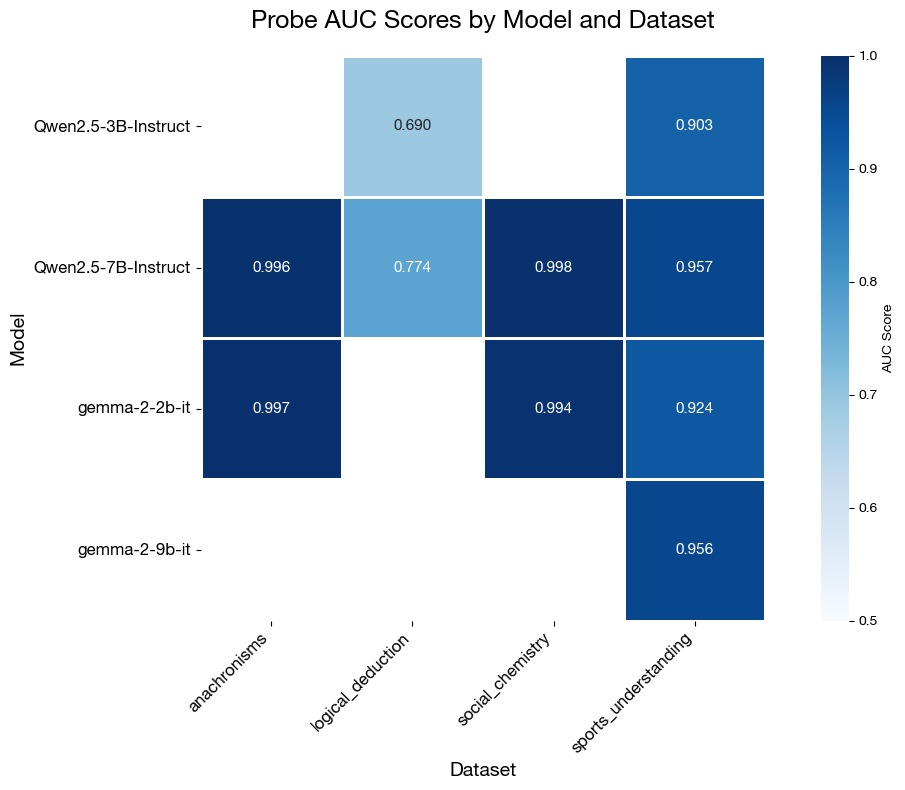

Saved AUC heatmap to visualizations/auc_heatmap.png


<Figure size 640x480 with 0 Axes>

In [230]:
# Create a heatmap of AUC scores
if not auc_df.empty:
    # Pivot the data for heatmap
    pivot_df = auc_df.pivot(index='Model_Short', columns='Dataset', values='Best_AUC')
    
    # Create figure with white background - BACK TO ORIGINAL SIZE
    plt.figure(figsize=(12, 8))  # Back to original
    fig = plt.gcf()
    fig.patch.set_facecolor('white')
    
    # Create heatmap with a better color scheme
    sns.heatmap(pivot_df, 
                annot=True, 
                fmt='.3f', 
                cmap='Blues',  # Use blues to match the bar charts
                vmin=0.5, 
                vmax=1.0,
                cbar_kws={'label': 'AUC Score'},
                square=True,
                linewidths=1,
                linecolor='white',
                annot_kws={'fontsize': 11, 'fontweight': 'normal'})  # Back to original
    
    plt.title('Probe AUC Scores by Model and Dataset', 
              fontsize=18, fontweight='normal', pad=20, color='black')  # Back to original
    plt.xlabel('Dataset', fontsize=14, fontweight='normal', color='black')  # Back to original
    plt.ylabel('Model', fontsize=14, fontweight='normal', color='black')  # Back to original
    plt.xticks(rotation=45, ha='right', fontsize=12, color='black')  # Back to original
    plt.yticks(rotation=0, fontsize=12, color='black')  # Back to original
    
    # Remove the default box around the plot
    ax = plt.gca()
    for spine in ax.spines.values():
        spine.set_visible(False)
    
    plt.tight_layout()
    plt.show()
    
    # Save the heatmap
    plt.savefig('visualizations/auc_heatmap.png', dpi=300, bbox_inches='tight', facecolor='white')
    print("Saved AUC heatmap to visualizations/auc_heatmap.png")

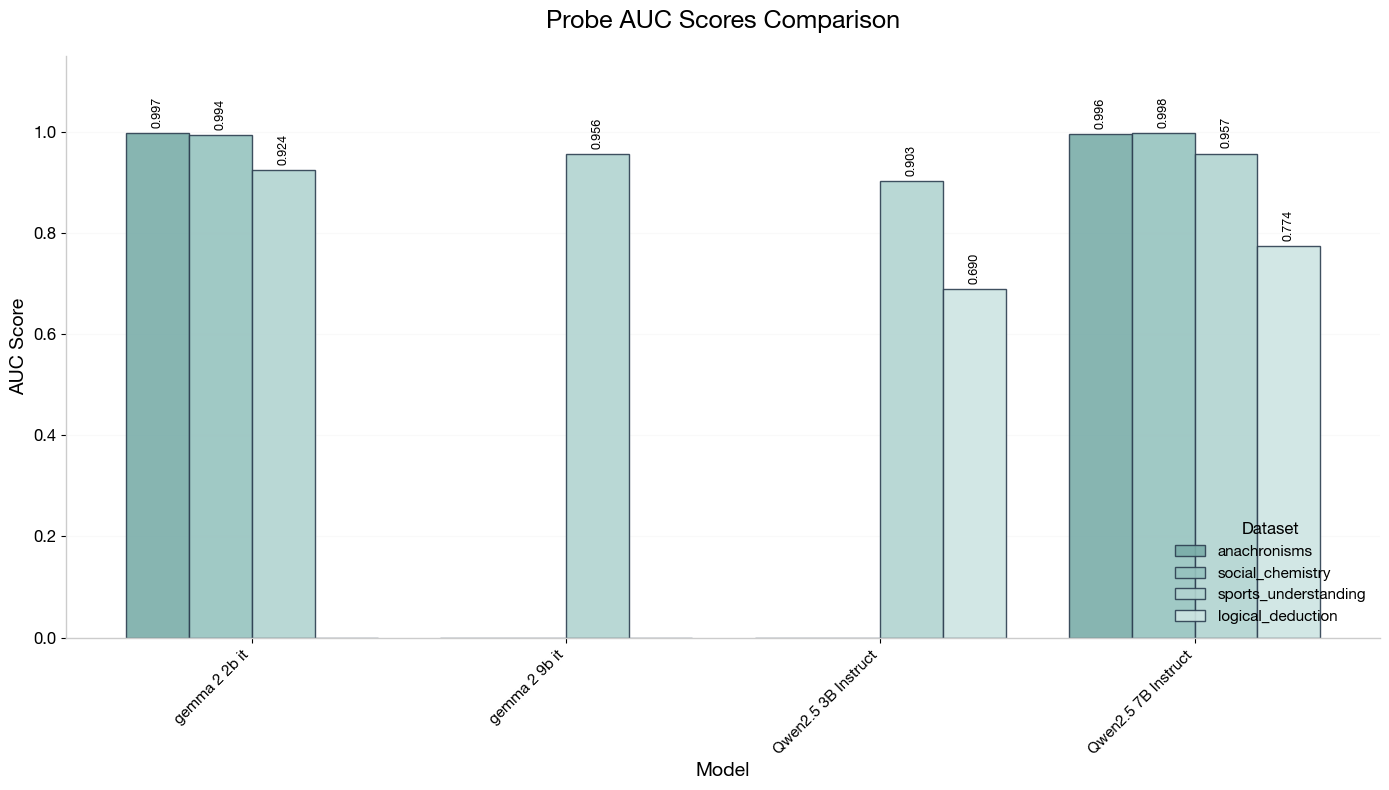

Saved AUC comparison bar chart to visualizations/auc_comparison_bars.png


<Figure size 640x480 with 0 Axes>

In [231]:
# Create bar chart comparing models across datasets
if not auc_df.empty:
    fig, ax = plt.subplots(figsize=(14, 8))  # Back to original
    fig.patch.set_facecolor('white')
    ax.set_facecolor('white')
    
    # Get unique models and datasets
    models = auc_df['Model_Short'].unique()
    datasets = auc_df['Dataset'].unique()
    
    # Set up bar positions
    x = np.arange(len(models))
    width = 0.2
    offsets = np.linspace(-width*1.5, width*1.5, len(datasets))
    
    # Color palette - variations of the new blue (122, 173, 169)
    colors = ['#7AADA9', '#96C3BF', '#B2D4D1', '#CEE5E3']
    
    # Create bars for each dataset
    for i, dataset in enumerate(datasets):
        dataset_data = auc_df[auc_df['Dataset'] == dataset]
        values = []
        for model in models:
            model_data = dataset_data[dataset_data['Model_Short'] == model]
            if not model_data.empty:
                values.append(model_data['Best_AUC'].iloc[0])
            else:
                values.append(0)  # Missing data
        
        bars = ax.bar(x + offsets[i], values, width, 
                      label=dataset, alpha=0.9,  # Almost opaque (0.1 transparency)
                      color=colors[i % len(colors)],
                      edgecolor='#2C3E50', linewidth=1)
        
        # Add value labels
        for bar, value in zip(bars, values):
            if value > 0:
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                       f'{value:.3f}', ha='center', va='bottom', 
                       fontsize=9, rotation=90, fontweight='normal', color='black')  # Back to original
    
    ax.set_xlabel('Model', fontsize=14, fontweight='normal', color='black')  # Back to original
    ax.set_ylabel('AUC Score', fontsize=14, fontweight='normal', color='black')  # Back to original
    ax.set_title('Probe AUC Scores Comparison', fontsize=18, fontweight='normal', pad=20, color='black')  # Back to original
    ax.set_xticks(x)
    ax.set_xticklabels([m.replace('-', ' ') for m in models], 
                       rotation=45, ha='right', fontsize=11, color='black')  # Back to original
    
    # Improve legend - place inside plot area
    ax.legend(title='Dataset', loc='lower right',
              frameon=False, fontsize=11,  # No frame, back to original size
              title_fontsize=12)
    
    ax.set_ylim(0, 1.15)
    
    # Add subtle grid
    ax.grid(True, axis='y', alpha=0.3, linestyle='-', linewidth=0.8)
    ax.set_axisbelow(True)
    
    # Remove top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_color('#CCCCCC')
    ax.spines['left'].set_color('#CCCCCC')
    
    # Set y-ticks
    ax.set_yticks(np.arange(0, 1.2, 0.2))
    ax.set_yticklabels([f'{y:.1f}' for y in np.arange(0, 1.2, 0.2)], 
                       fontsize=12, color='black')  # Back to original
    
    plt.tight_layout()
    plt.show()
    
    # Save the bar chart
    plt.savefig('visualizations/auc_comparison_bars.png', dpi=300, bbox_inches='tight', facecolor='white')
    print("Saved AUC comparison bar chart to visualizations/auc_comparison_bars.png")

In [232]:
# Display summary statistics for AUC scores
if not auc_df.empty:
    print("\nAUC Score Summary Statistics:")
    print("-" * 50)
    
    # Overall statistics
    print(f"\nOverall AUC: {auc_df['Best_AUC'].mean():.3f} ± {auc_df['Best_AUC'].std():.3f}")
    print(f"Best AUC: {auc_df['Best_AUC'].max():.3f}")
    print(f"Worst AUC: {auc_df['Best_AUC'].min():.3f}")
    
    # By model
    print("\nBy Model:")
    model_stats = auc_df.groupby('Model_Short')['Best_AUC'].agg(['mean', 'std', 'count'])
    for model, stats in model_stats.iterrows():
        print(f"  {model}: {stats['mean']:.3f} ± {stats['std']:.3f} (n={int(stats['count'])})")
    
    # By dataset
    print("\nBy Dataset:")
    dataset_stats = auc_df.groupby('Dataset')['Best_AUC'].agg(['mean', 'std', 'count'])
    for dataset, stats in dataset_stats.iterrows():
        print(f"  {dataset}: {stats['mean']:.3f} ± {stats['std']:.3f} (n={int(stats['count'])})")
    
    # Best performing model-dataset combinations
    print("\nTop 5 Model-Dataset Combinations:")
    top_combos = auc_df.nlargest(5, 'Best_AUC')[['Model_Short', 'Dataset', 'Best_AUC', 'Best_Layer']]
    for _, row in top_combos.iterrows():
        print(f"  {row['Model_Short']} - {row['Dataset']}: {row['Best_AUC']:.3f} (Layer {row['Best_Layer']})")


AUC Score Summary Statistics:
--------------------------------------------------

Overall AUC: 0.919 ± 0.106
Best AUC: 0.998
Worst AUC: 0.690

By Model:
  Qwen2.5-3B-Instruct: 0.796 ± 0.151 (n=2)
  Qwen2.5-7B-Instruct: 0.931 ± 0.106 (n=4)
  gemma-2-2b-it: 0.971 ± 0.042 (n=3)
  gemma-2-9b-it: 0.956 ± nan (n=1)

By Dataset:
  anachronisms: 0.997 ± 0.001 (n=2)
  logical_deduction: 0.732 ± 0.060 (n=2)
  social_chemistry: 0.996 ± 0.003 (n=2)
  sports_understanding: 0.935 ± 0.026 (n=4)

Top 5 Model-Dataset Combinations:
  Qwen2.5-7B-Instruct - social_chemistry: 0.998 (Layer 20)
  gemma-2-2b-it - anachronisms: 0.997 (Layer 14)
  Qwen2.5-7B-Instruct - anachronisms: 0.996 (Layer 19)
  gemma-2-2b-it - social_chemistry: 0.994 (Layer 14)
  Qwen2.5-7B-Instruct - sports_understanding: 0.957 (Layer 20)


# Steering Coverage Summary

This section shows which alpha values have been run for each model, dataset, and direction, along with the number of samples for each.

In [233]:
# Collect steering coverage data
coverage_data = []

for model in MODELS:
    for dataset in DATASETS:
        # Load steering results
        results = load_steering_results(model, dataset)
        
        if not results:
            continue
        
        print()
        print(f"Model: {model}, Dataset: {dataset}")
        # Process each direction
        for direction in ["yes", "no"]:
            if direction in results:
                # Sort by alpha value
                alpha_data = sorted(results[direction], key=lambda x: x[0])
                
                for alpha, data in alpha_data:
                    if alpha == 0:
                        print(f"{direction} samples: ", len(results[direction]))
                    coverage_data.append({
                        'Model': model.split('/')[-1],
                        'Dataset': dataset,
                        'Direction': direction,
                        'Alpha': alpha,
                        'Samples': len(data),
                        'Valid Parses': sum(1 for item in data if item.get('is_valid_parse', False)),
                        'Successes': sum(1 for item in data if item.get('success', False))
                    })

# Create DataFrame for coverage
coverage_df = pd.DataFrame(coverage_data)

# Display summary by model and dataset
print("STEERING COVERAGE SUMMARY")
print("=" * 100)

for model in coverage_df['Model'].unique():
    print(f"\n📊 MODEL: {model}")
    print("-" * 80)
    
    model_data = coverage_df[coverage_df['Model'] == model]
    
    for dataset in model_data['Dataset'].unique():
        print(f"\n  📁 Dataset: {dataset}")
        
        dataset_data = model_data[model_data['Dataset'] == dataset]
        
        # YES direction
        yes_data = dataset_data[dataset_data['Direction'] == 'yes']
        if not yes_data.empty:
            print(f"\n    ➡️  YES → NO Direction:")
            print(f"    Alpha values: {sorted(yes_data['Alpha'].tolist())}")
            print(f"    Total samples: {yes_data['Samples'].sum()}")
            print(f"    Samples per alpha: {dict(zip(yes_data['Alpha'], yes_data['Samples']))}")
            print(f"    Valid parses: {yes_data['Valid Parses'].sum()}/{yes_data['Samples'].sum()} ({yes_data['Valid Parses'].sum()/yes_data['Samples'].sum()*100:.1f}%)")
        
        # NO direction  
        no_data = dataset_data[dataset_data['Direction'] == 'no']
        if not no_data.empty:
            print(f"\n    ➡️  NO → YES Direction:")
            print(f"    Alpha values: {sorted(no_data['Alpha'].tolist())}")
            print(f"    Total samples: {no_data['Samples'].sum()}")
            print(f"    Samples per alpha: {dict(zip(no_data['Alpha'], no_data['Samples']))}")
            print(f"    Valid parses: {no_data['Valid Parses'].sum()}/{no_data['Samples'].sum()} ({no_data['Valid Parses'].sum()/no_data['Samples'].sum()*100:.1f}%)")

STEERING COVERAGE SUMMARY

📊 MODEL: gemma-2-2b-it
--------------------------------------------------------------------------------

  📁 Dataset: anachronisms

    ➡️  YES → NO Direction:
    Alpha values: [0.0, 2.0, 4.0, 6.0, 8.0, 10.0, 12.0, 14.0, 16.0, 18.0, 20.0]
    Total samples: 1636
    Samples per alpha: {0.0: 246, 2.0: 139, 4.0: 139, 6.0: 139, 8.0: 139, 10.0: 139, 12.0: 139, 14.0: 139, 16.0: 139, 18.0: 139, 20.0: 139}
    Valid parses: 642/1636 (39.2%)

    ➡️  NO → YES Direction:
    Alpha values: [0.0, 2.0, 4.0, 6.0, 8.0, 10.0, 12.0, 14.0, 16.0, 18.0, 20.0]
    Total samples: 2599
    Samples per alpha: {0.0: 139, 2.0: 246, 4.0: 246, 6.0: 246, 8.0: 246, 10.0: 246, 12.0: 246, 14.0: 246, 16.0: 246, 18.0: 246, 20.0: 246}
    Valid parses: 634/2599 (24.4%)

  📁 Dataset: sports_understanding

    ➡️  YES → NO Direction:
    Alpha values: [0.0, 2.0, 4.0, 6.0, 8.0, 10.0, 12.0, 14.0, 16.0]
    Total samples: 1453
    Samples per alpha: {0.0: 229, 2.0: 153, 4.0: 153, 6.0: 153, 8.0: 1

ValueError: Unknown format code 'd' for object of type 'float'

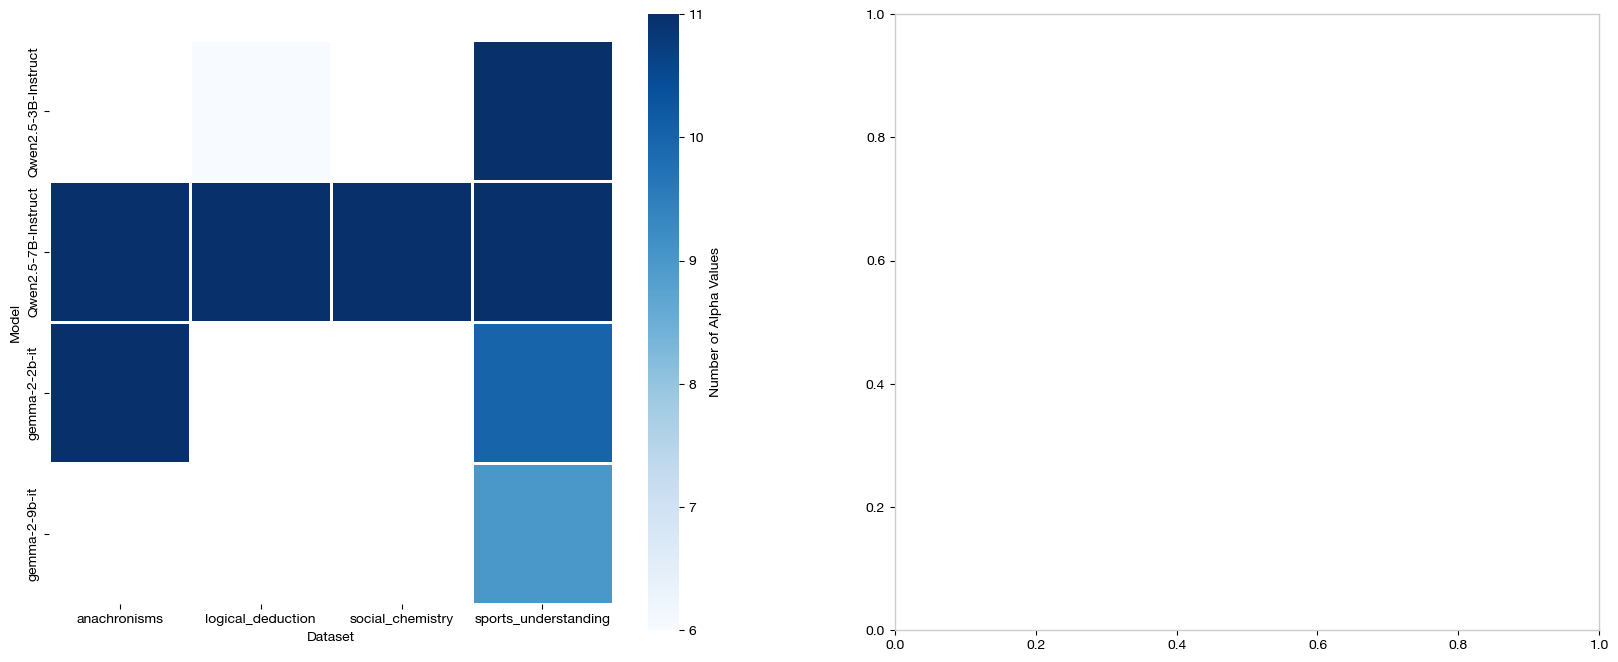

In [234]:
# Create a heatmap showing steering coverage
if not coverage_df.empty:
    # Prepare data for heatmap
    # Create a pivot table with models as rows, datasets as columns, and alpha coverage as values
    coverage_summary = []
    
    for model in coverage_df['Model'].unique():
        for dataset in coverage_df['Dataset'].unique():
            model_dataset_data = coverage_df[(coverage_df['Model'] == model) & (coverage_df['Dataset'] == dataset)]
            
            if not model_dataset_data.empty:
                # Get unique alpha values for both directions
                yes_alphas = set(model_dataset_data[model_dataset_data['Direction'] == 'yes']['Alpha'].tolist())
                no_alphas = set(model_dataset_data[model_dataset_data['Direction'] == 'no']['Alpha'].tolist())
                all_alphas = sorted(yes_alphas.union(no_alphas))
                
                # Count total samples
                total_samples = model_dataset_data['Samples'].sum()
                
                coverage_summary.append({
                    'Model': model,
                    'Dataset': dataset,
                    'Alpha Count': len(all_alphas),
                    'Total Samples': total_samples,
                    'Alpha Range': f"[{min(all_alphas):.0f}, {max(all_alphas):.0f}]" if all_alphas else "None"
                })
    
    # Create summary DataFrame
    summary_df = pd.DataFrame(coverage_summary)
    
    if not summary_df.empty:
        # Pivot for alpha count heatmap
        pivot_alpha = summary_df.pivot(index='Model', columns='Dataset', values='Alpha Count')
        
        # Create figure with subplots
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
        fig.patch.set_facecolor('white')
        
        # Heatmap 1: Number of alpha values tested
        sns.heatmap(pivot_alpha, 
                    annot=True, 
                    fmt='d', 
                    cmap='Blues',
                    cbar_kws={'label': 'Number of Alpha Values'},
                    square=True,
                    linewidths=1,
                    linecolor='white',
                    ax=ax1,
                    annot_kws={'fontsize': 11})
        
        ax1.set_title('Number of Alpha Values Tested per Model-Dataset', 
                      fontsize=16, fontweight='normal', pad=20)
        ax1.set_xlabel('Dataset', fontsize=14)
        ax1.set_ylabel('Model', fontsize=14)
        
        # Heatmap 2: Total samples
        pivot_samples = summary_df.pivot(index='Model', columns='Dataset', values='Total Samples')
        
        sns.heatmap(pivot_samples, 
                    annot=True, 
                    fmt='d', 
                    cmap='Greens',
                    cbar_kws={'label': 'Total Samples'},
                    square=True,
                    linewidths=1,
                    linecolor='white',
                    ax=ax2,
                    annot_kws={'fontsize': 11})
        
        ax2.set_title('Total Steering Samples per Model-Dataset', 
                      fontsize=16, fontweight='normal', pad=20)
        ax2.set_xlabel('Dataset', fontsize=14)
        ax2.set_ylabel('Model', fontsize=14)
        
        plt.tight_layout()
        plt.show()
        
        # Save the coverage heatmaps
        plt.savefig('visualizations/steering_coverage_heatmap.png', dpi=300, bbox_inches='tight', facecolor='white')
        print("\\nSaved coverage heatmap to visualizations/steering_coverage_heatmap.png")

In [ ]:
# Identify missing alpha values (gaps in coverage)
print("\nMISSING ALPHA VALUES")
print("=" * 100)

# Expected alpha range (based on configs)
expected_alphas = [0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20]

for model in coverage_df['Model'].unique():
    model_has_gaps = False
    model_gaps = []
    
    for dataset in coverage_df['Dataset'].unique():
        dataset_data = coverage_df[(coverage_df['Model'] == model) & (coverage_df['Dataset'] == dataset)]
        
        if dataset_data.empty:
            model_gaps.append(f"  ❌ {dataset}: No steering data found")
            model_has_gaps = True
            continue
        
        # Check each direction
        for direction in ['yes', 'no']:
            dir_data = dataset_data[dataset_data['Direction'] == direction]
            if dir_data.empty:
                model_gaps.append(f"  ❌ {dataset} ({direction}): No data for this direction")
                model_has_gaps = True
                continue
                
            actual_alphas = set(dir_data['Alpha'].tolist())
            missing_alphas = [a for a in expected_alphas if a not in actual_alphas]
            
            if missing_alphas:
                model_gaps.append(f"  ⚠️  {dataset} ({direction}): Missing alphas {missing_alphas}")
                model_has_gaps = True
                
                # Check if it might be due to early stopping
                if missing_alphas == expected_alphas[len(actual_alphas):]:
                    model_gaps[-1] += " (possibly due to early stopping)"
    
    if model_has_gaps:
        print(f"\n📊 {model}:")
        for gap in model_gaps:
            print(gap)
    else:
        print(f"\n✅ {model}: Complete coverage")

In [ ]:
# Export coverage data to CSV for further analysis
if not coverage_df.empty:
    # Create sheets directory if not exists
    sheets_dir = Path("results/sheets")
    sheets_dir.mkdir(parents=True, exist_ok=True)
    
    # Save detailed coverage data
    coverage_df.to_csv(sheets_dir / 'steering_coverage_detailed.csv', index=False)
    print(f"\nExported detailed coverage data to: {sheets_dir}/steering_coverage_detailed.csv")
    
    # Create and save summary table
    summary_table = coverage_df.groupby(['Model', 'Dataset', 'Direction']).agg({
        'Alpha': lambda x: f"{min(x):.0f}-{max(x):.0f}",
        'Samples': 'sum',
        'Valid Parses': 'sum',
        'Successes': 'sum'
    }).rename(columns={'Alpha': 'Alpha Range'})
    
    summary_table['Parse Rate'] = (summary_table['Valid Parses'] / summary_table['Samples'] * 100).round(1)
    summary_table['Success Rate'] = (summary_table['Successes'] / summary_table['Valid Parses'] * 100).round(1)
    
    summary_table.to_csv(sheets_dir / 'steering_coverage_summary.csv')
    print(f"Exported coverage summary to: {sheets_dir}/steering_coverage_summary.csv")
    
    # Display a sample of the summary
    print("\nSample of coverage summary:")
    print(summary_table.head(10))

# Export Results to CSV Template

This section creates a structured CSV file with experiment results, filtering out any results with ≤ 50 samples per generation at a given alpha value.

In [ ]:
# Create comprehensive results CSV with filtering
MIN_SAMPLES = 50  # Minimum number of samples required

results_for_csv = []

for model in MODELS:
    for dataset in DATASETS:
        # Load steering results
        results = load_steering_results(model, dataset)
        
        if not results:
            continue
        
        # Load AUC scores for this model-dataset combination
        auc_scores = load_auc_scores(model, dataset)
        if auc_scores and isinstance(auc_scores, list):
            best_auc = max(auc_scores)
            best_layer = auc_scores.index(best_auc)
        else:
            best_auc = None
            best_layer = None
        
        # Process each direction
        for direction in ["yes", "no"]:
            if direction in results:
                # Sort by alpha value
                alpha_data = sorted(results[direction], key=lambda x: x[0])
                
                for alpha, data in alpha_data:
                    # Skip if not enough samples
                    if len(data) <= MIN_SAMPLES:
                        print(f"Skipping {model.split('/')[-1]} - {dataset} - {direction} - α={alpha}: Only {len(data)} samples")
                        continue
                    
                    # Calculate metrics
                    no_parse_rate, success_rate, no_parse_ci, success_ci = calculate_metrics(data)
                    
                    # Count actual values
                    total_samples = len(data)
                    valid_parses = sum(1 for item in data if item.get('is_valid_parse', False))
                    successes = sum(1 for item in data if item.get('success', False))
                    
                    # Create row for CSV
                    results_for_csv.append({
                        'Model': model,
                        'Model_Short': model.split('/')[-1],
                        'Dataset': dataset,
                        'Direction': f"{direction}→{'no' if direction == 'yes' else 'yes'}",
                        'Alpha': alpha,
                        'N_Samples': total_samples,
                        'N_Valid_Parses': valid_parses,
                        'N_Successes': successes,
                        'Parse_Rate': round(valid_parses / total_samples * 100, 2) if total_samples > 0 else 0.0,
                        'Failed_Parse_Rate': round(no_parse_rate * 100, 2),
                        'Success_Rate': round(success_rate * 100, 2),
                        'Success_Rate_CI': round(success_ci * 100, 2),
                        'Failed_Parse_CI': round(no_parse_ci * 100, 2),
                        'Probe_AUC': round(best_auc, 3) if best_auc else None,
                        'Best_Layer': best_layer
                    })

# Create DataFrame
results_csv_df = pd.DataFrame(results_for_csv)

# Sort for better organization
results_csv_df = results_csv_df.sort_values(['Model_Short', 'Dataset', 'Direction', 'Alpha'])

print(f"\nCreated results table with {len(results_csv_df)} rows")
print(f"Filtered out results with ≤ {MIN_SAMPLES} samples")

# Display first few rows
print("\nFirst 10 rows of results table:")
results_csv_df.head(10)

In [235]:
# Create output directory for sheets
sheets_dir = Path("results/sheets")
sheets_dir.mkdir(parents=True, exist_ok=True)

# Save to CSV file
output_csv_path = sheets_dir / "results_populated.csv"
results_csv_df.to_csv(output_csv_path, index=False)
print(f"\nSaved populated results to: {output_csv_path}")

# Create a summary by model and dataset
summary_by_model = results_csv_df.groupby(['Model_Short', 'Dataset']).agg({
    'N_Samples': 'sum',
    'Alpha': 'count',
    'Success_Rate': 'mean',
    'Failed_Parse_Rate': 'mean',
    'Probe_AUC': 'first'
}).round(2).rename(columns={'Alpha': 'N_Experiments'})

print("\nSummary by Model and Dataset:")
print(summary_by_model)


Saved populated results to: results/sheets/results_populated.csv

Summary by Model and Dataset:
                                          N_Samples  N_Experiments  \
Model_Short         Dataset                                          
Qwen2.5-3B-Instruct logical_deduction          2191             11   
                    sports_understanding       4455             22   
Qwen2.5-7B-Instruct social_chemistry           4310             20   
gemma-2-2b-it       anachronisms               4235             22   
                    sports_understanding       3667             19   

                                          Success_Rate  Failed_Parse_Rate  \
Model_Short         Dataset                                                 
Qwen2.5-3B-Instruct logical_deduction            21.69               2.26   
                    sports_understanding         57.18              26.74   
Qwen2.5-7B-Instruct social_chemistry             28.83              68.79   
gemma-2-2b-it       anachro

In [236]:
# Create a pivot table for better visualization
pivot_success = results_csv_df.pivot_table(
    values='Success_Rate', 
    index=['Model_Short', 'Dataset'], 
    columns=['Direction', 'Alpha'],
    aggfunc='mean'
)

print("\nSteering Success Rates (%) by Model, Dataset, Direction, and Alpha:")
print(pivot_success.round(1))


Steering Success Rates (%) by Model, Dataset, Direction, and Alpha:
Direction                                no→yes                             \
Alpha                                      0.0   2.0    4.0    6.0    8.0    
Model_Short         Dataset                                                  
Qwen2.5-3B-Instruct logical_deduction       6.9  24.1   32.7   36.4   43.9   
                    sports_understanding    9.0  17.4   47.9   64.1   70.6   
Qwen2.5-7B-Instruct social_chemistry        1.6  42.2  100.0  100.0  100.0   
gemma-2-2b-it       anachronisms           16.2  88.7   92.4   93.8  100.0   
                    sports_understanding   12.4  18.3   39.7   72.0   95.6   

Direction                                                                 ...  \
Alpha                                     10.0  12.0  14.0   16.0   18.0  ...   
Model_Short         Dataset                                               ...   
Qwen2.5-3B-Instruct logical_deduction     43.7   NaN   NaN    N

In [237]:
# Additional filtering: Show only high-quality results (>100 samples)
high_quality_df = results_csv_df[results_csv_df['N_Samples'] > 100].copy()

if not high_quality_df.empty:
    print(f"\nHigh-quality results (>100 samples): {len(high_quality_df)} rows")
    
    # Save high-quality results separately
    high_quality_path = sheets_dir / "results_high_quality.csv"
    high_quality_df.to_csv(high_quality_path, index=False)
    print(f"Saved high-quality results to: {high_quality_path}")
    
    # Show summary statistics for high-quality results
    print("\nHigh-Quality Results Summary:")
    print(f"  Models: {high_quality_df['Model_Short'].nunique()}")
    print(f"  Datasets: {high_quality_df['Dataset'].nunique()}")
    print(f"  Total samples: {high_quality_df['N_Samples'].sum():,}")
    print(f"  Average success rate: {high_quality_df['Success_Rate'].mean():.1f}%")
    print(f"  Average failed parse rate: {high_quality_df['Failed_Parse_Rate'].mean():.1f}%")
else:
    print("\nNo results with >100 samples found")


High-quality results (>100 samples): 94 rows
Saved high-quality results to: results/sheets/results_high_quality.csv

High-Quality Results Summary:
  Models: 3
  Datasets: 4
  Total samples: 18,858
  Average success rate: 44.4%
  Average failed parse rate: 39.3%


In [238]:
# Create a formatted Excel-style summary table
formatted_results = results_csv_df.copy()

# Format numeric columns for better readability
formatted_results['Parse_Rate_Str'] = formatted_results['Parse_Rate'].apply(lambda x: f"{x:.1f}%")
formatted_results['Success_Rate_Str'] = formatted_results['Success_Rate'].apply(lambda x: f"{x:.1f}%")
formatted_results['Failed_Parse_Rate_Str'] = formatted_results['Failed_Parse_Rate'].apply(lambda x: f"{x:.1f}%")
formatted_results['Probe_AUC_Str'] = formatted_results['Probe_AUC'].apply(lambda x: f"{x:.3f}" if pd.notna(x) else "N/A")

# Select and reorder columns for the final table
final_columns = [
    'Model_Short', 'Dataset', 'Direction', 'Alpha', 
    'N_Samples', 'Parse_Rate_Str', 'Failed_Parse_Rate_Str', 
    'Success_Rate_Str', 'Probe_AUC_Str', 'Best_Layer'
]

final_table = formatted_results[final_columns].rename(columns={
    'Model_Short': 'Model',
    'N_Samples': 'Samples',
    'Parse_Rate_Str': 'Parse Rate',
    'Failed_Parse_Rate_Str': 'Failed Parse',
    'Success_Rate_Str': 'Success Rate',
    'Probe_AUC_Str': 'Probe AUC',
    'Best_Layer': 'Layer'
})

# Save the formatted table
formatted_path = sheets_dir / "results_formatted.csv"
final_table.to_csv(formatted_path, index=False)
print(f"\nSaved formatted results table to: {formatted_path}")

# Display sample of formatted table
print("\nSample of formatted results table:")
print(final_table.head(15).to_string())


Saved formatted results table to: results/sheets/results_formatted.csv

Sample of formatted results table:
                  Model               Dataset Direction  Alpha  Samples Parse Rate Failed Parse Success Rate Probe AUC  Layer
46  Qwen2.5-3B-Instruct     logical_deduction    no→yes    0.0      305      99.7%         0.3%         6.9%     0.690     27
47  Qwen2.5-3B-Instruct     logical_deduction    no→yes    2.0      111      97.3%         2.7%        24.1%     0.690     27
48  Qwen2.5-3B-Instruct     logical_deduction    no→yes    4.0      111      99.1%         0.9%        32.7%     0.690     27
49  Qwen2.5-3B-Instruct     logical_deduction    no→yes    6.0      111      96.4%         3.6%        36.5%     0.690     27
50  Qwen2.5-3B-Instruct     logical_deduction    no→yes    8.0      111      96.4%         3.6%        43.9%     0.690     27
51  Qwen2.5-3B-Instruct     logical_deduction    no→yes   10.0      111      92.8%         7.2%        43.7%     0.690     27
41  Qwen2.

In [239]:
# Create template-matching format with proper Yes/No pairing and consistent sample sizes
print("\n" + "=" * 80)
print("Creating Template-Matching CSV Format with Accuracy and Sample Sizes")
print("=" * 80)

# Initialize the template structure
template_rows = []

# First create header rows
header1 = ['', '', 'Train Acc.', 'Test Acc.', 'Best Probe Layer', 'Best Probe AUC', 'Direction', 'N']
header2 = ['', '', '', '', '', '', '', '']

# Add alpha value columns (0 to 20)
for alpha in range(21):
    header1.extend([str(alpha), ''])
    header2.extend(['Success', 'Unparsed'])

# Process each model
for model in MODELS:
    model_short = model.split('/')[-1]
    model_first_row = True
    
    for dataset in DATASETS:
        # Load results for this model-dataset
        results = load_steering_results(model, dataset)
        
        if not results:
            continue
        
        # Find the maximum sample size for each direction
        yes_max_n = 0
        no_max_n = 0
        
        print()
        if 'yes' in results:
            # Get all sample counts for yes direction
            yes_sample_counts = {alpha: len(data) for alpha, data in results['yes']}
            if yes_sample_counts:
                print("Yes Sample Counts: ", yes_sample_counts)
                yes_max_n = max(yes_sample_counts.values())
        
        if 'no' in results:
            # Get all sample counts for no direction  
            no_sample_counts = {alpha: len(data) for alpha, data in results['no']}
            if no_sample_counts:
                print("No Sample Counts: ", no_sample_counts)
                no_max_n = max(no_sample_counts.values())
        
        # Skip if both max N values are too small
        if yes_max_n <= MIN_SAMPLES and no_max_n <= MIN_SAMPLES:
            continue
            
        # Load generation accuracy
        accuracies = load_generation_accuracy(model, dataset)
        train_acc = accuracies['train'] if accuracies['train'] is not None else ''
        test_acc = accuracies['test'] if accuracies['test'] is not None else ''
            
        # Load AUC scores
        auc_scores = load_auc_scores(model, dataset)
        if auc_scores and isinstance(auc_scores, list):
            best_auc = round(max(auc_scores), 3)
            best_layer = auc_scores.index(max(auc_scores))
        else:
            best_auc = ''
            best_layer = ''
        
        # Process YES direction first
        yes_row = [
            model_short if model_first_row else '',  # Only show model name once
            dataset,
            train_acc,  # Train Acc
            test_acc,   # Test Acc
            best_layer,
            best_auc,
            'Yes',
            yes_max_n if yes_max_n > 0 else ''  # Show actual max N for YES direction
        ]
        
        # Collect YES results - only include alphas with yes_max_n samples
        yes_results_by_alpha = {}
        if 'yes' in results and yes_max_n > MIN_SAMPLES:
            for alpha, data in results['yes']:
                # Only include if this alpha has the full sample size for YES
                if len(data) == yes_max_n:
                    no_parse_rate, success_rate, _, _ = calculate_metrics(data)
                    yes_results_by_alpha[alpha] = {
                        'success': round(success_rate * 100, 1),
                        'unparsed': round(no_parse_rate * 100, 1)
                    }
                elif len(data) > 0:
                    # Mark incomplete data
                    print(f"  Skipping {model_short}/{dataset}/Yes/α={alpha}: only {len(data)}/{yes_max_n} samples")
        
        # Fill in alpha columns for YES
        for alpha in range(21):
            if alpha in yes_results_by_alpha:
                yes_row.extend([yes_results_by_alpha[alpha]['success'], 
                               yes_results_by_alpha[alpha]['unparsed']])
            else:
                yes_row.extend(['', ''])
        
        # Process NO direction (immediately after YES for same dataset)
        no_row = [
            '',  # No model name
            '',  # No dataset name (implied from YES row above)
            '',  # Train Acc (same as YES)
            '',  # Test Acc (same as YES)
            '',  # No probe layer (same as YES)
            '',  # No probe AUC (same as YES)
            'No',
            no_max_n if no_max_n > 0 else ''  # Show actual max N for NO direction
        ]
        
        # Collect NO results - only include alphas with no_max_n samples
        no_results_by_alpha = {}
        if 'no' in results and no_max_n > MIN_SAMPLES:
            for alpha, data in results['no']:
                # Only include if this alpha has the full sample size for NO
                if len(data) == no_max_n:
                    no_parse_rate, success_rate, _, _ = calculate_metrics(data)
                    no_results_by_alpha[alpha] = {
                        'success': round(success_rate * 100, 1),
                        'unparsed': round(no_parse_rate * 100, 1)
                    }
                elif len(data) > 0:
                    # Mark incomplete data
                    print(f"  Skipping {model_short}/{dataset}/No/α={alpha}: only {len(data)}/{no_max_n} samples")
        
        # Fill in alpha columns for NO
        for alpha in range(21):
            if alpha in no_results_by_alpha:
                no_row.extend([no_results_by_alpha[alpha]['success'],
                              no_results_by_alpha[alpha]['unparsed']])
            else:
                no_row.extend(['', ''])
        
        # Only add rows if we have at least some data to show
        if yes_max_n > 0 or no_max_n > 0:
            template_rows.append(yes_row)
            template_rows.append(no_row)
            model_first_row = False

# Create DataFrame with headers
template_df = pd.DataFrame(template_rows)
template_df.columns = range(len(template_df.columns))

# Insert header rows at the beginning
header_df = pd.DataFrame([header1, header2])
header_df.columns = range(len(header_df.columns))

final_template_df = pd.concat([header_df, template_df], ignore_index=True)

# Save to CSV in sheets directory
template_path = sheets_dir / "results_template_format.csv"
final_template_df.to_csv(template_path, index=False, header=False)
print(f"\nSaved template-matching format to: {template_path}")

# Display sample
print("\nFirst 20 rows of template-format CSV (first 17 columns):")
print(final_template_df.iloc[:20, :17].to_string(index=False, header=False))

# Show count of model-dataset pairs
unique_models = [row[0] for row in template_rows if row[0] != '']
unique_datasets = [row[1] for row in template_rows if row[1] != '']
print(f"\nIncluded {len(unique_models)} models with {len(unique_datasets)} dataset entries")
print("\nData quality controls:")
print(f"  - N column shows the actual maximum sample size for each direction")
print(f"  - Only alpha values with exactly N samples are included in results")
print(f"  - Results only shown if N > {MIN_SAMPLES}")
print(f"  - Yes and No directions may have different N values")
print("  - Empty cells indicate missing or incomplete data for that alpha")


Creating Template-Matching CSV Format with Accuracy and Sample Sizes

Yes Sample Counts:  {20.0: 139, 16.0: 139, 18.0: 139, 2.0: 139, 14.0: 139, 10.0: 139, 6.0: 139, 4.0: 139, 0.0: 246, 12.0: 139, 8.0: 139}
No Sample Counts:  {18.0: 246, 0.0: 139, 8.0: 246, 10.0: 246, 12.0: 246, 2.0: 246, 20.0: 246, 16.0: 246, 6.0: 246, 4.0: 246, 14.0: 246}
  Skipping gemma-2-2b-it/anachronisms/Yes/α=20.0: only 139/246 samples
  Skipping gemma-2-2b-it/anachronisms/Yes/α=16.0: only 139/246 samples
  Skipping gemma-2-2b-it/anachronisms/Yes/α=18.0: only 139/246 samples
  Skipping gemma-2-2b-it/anachronisms/Yes/α=2.0: only 139/246 samples
  Skipping gemma-2-2b-it/anachronisms/Yes/α=14.0: only 139/246 samples
  Skipping gemma-2-2b-it/anachronisms/Yes/α=10.0: only 139/246 samples
  Skipping gemma-2-2b-it/anachronisms/Yes/α=6.0: only 139/246 samples
  Skipping gemma-2-2b-it/anachronisms/Yes/α=4.0: only 139/246 samples
  Skipping gemma-2-2b-it/anachronisms/Yes/α=12.0: only 139/246 samples
  Skipping gemma-2-2

In [240]:
# Also create an Excel version for easier viewing
try:
    excel_path = sheets_dir / "results_template_format.xlsx"
    with pd.ExcelWriter(excel_path, engine='openpyxl') as writer:
        final_template_df.to_excel(writer, sheet_name='Results', index=False, header=False)
    print(f"\nAlso saved as Excel file: {excel_path}")
except Exception as e:
    print(f"\nCould not save Excel version: {e}")

# Print summary
print("\n" + "=" * 80)
print("SUMMARY")
print("=" * 80)
print(f"\nAll files saved to: {sheets_dir}/")
print(f"\nFiles created:")
print(f"  1. results_populated.csv - Detailed results with all metrics")
print(f"  2. results_high_quality.csv - Only results with >100 samples")
print(f"  3. results_formatted.csv - Nicely formatted for presentation")
print(f"  4. results_template_format.csv - Matches the original template structure")
if 'excel_path' in locals():
    print(f"  5. results_template_format.xlsx - Excel version of template format")

print(f"\nTemplate format details:")
print(f"  - Model name in first column (only shown once per model)")
print(f"  - Dataset name in second column")
print(f"  - Best Probe Layer and AUC in columns 5-6")
print(f"  - Direction (Yes/No) in column 7")
print(f"  - Alpha values 0-20 with Success/Unparsed pairs")
print(f"  - All results filtered to exclude experiments with ≤{MIN_SAMPLES} samples")


Also saved as Excel file: results/sheets/results_template_format.xlsx

SUMMARY

All files saved to: results/sheets/

Files created:
  1. results_populated.csv - Detailed results with all metrics
  2. results_high_quality.csv - Only results with >100 samples
  3. results_formatted.csv - Nicely formatted for presentation
  4. results_template_format.csv - Matches the original template structure
  5. results_template_format.xlsx - Excel version of template format

Template format details:
  - Model name in first column (only shown once per model)
  - Dataset name in second column
  - Best Probe Layer and AUC in columns 5-6
  - Direction (Yes/No) in column 7
  - Alpha values 0-20 with Success/Unparsed pairs
  - All results filtered to exclude experiments with ≤50 samples


# Create Filtered Results Cache

This section creates a new cache directory containing only experiments with sufficient sample sizes, making it easier to work with high-quality results.

In [ ]:
# Create filtered results cache with only sufficient sample sizes
import shutil
import json
from pathlib import Path

MIN_SAMPLES_FOR_CACHE = 50  # Minimum samples required to include in filtered cache
RESULTS_CACHE_DIR = Path("results_cache")

print("Creating filtered results cache...")
print("=" * 80)

# Track what we copy
copied_experiments = []
skipped_experiments = []

# Process each cache directory
for cache_name in ["cache/experiments", "new_cache/experiments"]:
    cache_dir = Path(cache_name)
    if not cache_dir.exists():
        continue
    
    print(f"\nProcessing {cache_name}...")
    
    # Iterate through all experiments
    for model_dir in cache_dir.iterdir():
        if not model_dir.is_dir():
            continue
            
        model_name = model_dir.name
        
        for dataset_dir in model_dir.iterdir():
            if not dataset_dir.is_dir():
                continue
                
            dataset_name = dataset_dir.name
            
            for split_dir in dataset_dir.iterdir():
                if not split_dir.is_dir() or not split_dir.name.startswith("split_"):
                    continue
                    
                split_name = split_dir.name
                
                for hash_dir in split_dir.iterdir():
                    if not hash_dir.is_dir() or len(hash_dir.name) < 10:
                        continue
                        
                    hash_name = hash_dir.name
                    steering_dir = hash_dir / "steering"
                    
                    if not steering_dir.exists():
                        continue
                    
                    # Check if this experiment has sufficient samples
                    has_sufficient_samples = False
                    max_samples = 0
                    
                    # Check all steering result files
                    for pkl_file in steering_dir.glob("*.pkl"):
                        try:
                            with open(pkl_file, 'rb') as f:
                                data = pickle.load(f)
                                if isinstance(data, list) and len(data) > max_samples:
                                    max_samples = len(data)
                                if len(data) > MIN_SAMPLES_FOR_CACHE:
                                    has_sufficient_samples = True
                        except:
                            continue
                    
                    if has_sufficient_samples:
                        # Create destination path
                        dest_path = RESULTS_CACHE_DIR / "experiments" / model_name / dataset_name / split_name / hash_name
                        
                        # Copy the entire experiment directory
                        if dest_path.exists():
                            print(f"  Skipping (already exists): {model_name}/{dataset_name}")
                        else:
                            dest_path.parent.mkdir(parents=True, exist_ok=True)
                            shutil.copytree(hash_dir, dest_path)
                            copied_experiments.append(f"{model_name}/{dataset_name}/{split_name}")
                            print(f"  ✓ Copied: {model_name}/{dataset_name} (max {max_samples} samples)")
                    else:
                        skipped_experiments.append(f"{model_name}/{dataset_name}/{split_name} (max {max_samples} samples)")

print("\n" + "=" * 80)
print("SUMMARY")
print("=" * 80)
print(f"\nFiltered cache created at: {RESULTS_CACHE_DIR}/")
print(f"Minimum sample threshold: {MIN_SAMPLES_FOR_CACHE}")
print(f"\nCopied {len(copied_experiments)} experiments:")
for exp in sorted(set(copied_experiments)):
    print(f"  ✓ {exp}")

if skipped_experiments:
    print(f"\nSkipped {len(skipped_experiments)} experiments with insufficient samples:")
    for exp in sorted(set(skipped_experiments))[:10]:  # Show first 10
        print(f"  ✗ {exp}")
    if len(skipped_experiments) > 10:
        print(f"  ... and {len(skipped_experiments) - 10} more")

# Create a metadata file
metadata = {
    "created": pd.Timestamp.now().isoformat(),
    "min_samples": MIN_SAMPLES_FOR_CACHE,
    "source_dirs": ["cache/experiments", "new_cache/experiments"],
    "total_copied": len(copied_experiments),
    "total_skipped": len(skipped_experiments),
    "copied_experiments": sorted(set(copied_experiments)),
    "skipped_experiments": sorted(set(skipped_experiments))
}

metadata_path = RESULTS_CACHE_DIR / "metadata.json"
with open(metadata_path, 'w') as f:
    json.dump(metadata, f, indent=2)

print(f"\nMetadata saved to: {metadata_path}")

In [ ]:
# Alternative: Create filtered cache with per-file filtering
# This version copies experiments but only includes steering files with sufficient samples

FILTERED_CACHE_DIR = Path("filtered_results_cache")
MIN_SAMPLES_PER_FILE = 50

print("Creating filtered results cache (per-file filtering)...")
print("=" * 80)

# Track statistics
total_files_copied = 0
total_files_skipped = 0
experiments_with_data = []

# Process each cache directory
for cache_name in ["cache/experiments", "new_cache/experiments"]:
    cache_dir = Path(cache_name)
    if not cache_dir.exists():
        continue
    
    print(f"\nProcessing {cache_name}...")
    
    # Iterate through all experiments
    for model_dir in cache_dir.iterdir():
        if not model_dir.is_dir():
            continue
            
        model_name = model_dir.name
        
        for dataset_dir in model_dir.iterdir():
            if not dataset_dir.is_dir():
                continue
                
            dataset_name = dataset_dir.name
            
            for split_dir in dataset_dir.iterdir():
                if not split_dir.is_dir() or not split_dir.name.startswith("split_"):
                    continue
                    
                split_name = split_dir.name
                
                for hash_dir in split_dir.iterdir():
                    if not hash_dir.is_dir() or len(hash_dir.name) < 10:
                        continue
                        
                    hash_name = hash_dir.name
                    steering_dir = hash_dir / "steering"
                    
                    if not steering_dir.exists():
                        continue
                    
                    # Create destination path
                    dest_path = FILTERED_CACHE_DIR / "experiments" / model_name / dataset_name / split_name / hash_name
                    
                    # Track if we copy any files for this experiment
                    copied_any = False
                    
                    # Copy non-steering directories as-is
                    for subdir in hash_dir.iterdir():
                        if subdir.name != "steering" and subdir.is_dir():
                            dest_subdir = dest_path / subdir.name
                            if not dest_subdir.exists():
                                dest_subdir.parent.mkdir(parents=True, exist_ok=True)
                                shutil.copytree(subdir, dest_subdir)
                    
                    # Process steering files individually
                    dest_steering = dest_path / "steering"
                    
                    for pkl_file in steering_dir.glob("*.pkl"):
                        try:
                            with open(pkl_file, 'rb') as f:
                                data = pickle.load(f)
                            
                            # Only copy if sufficient samples
                            if isinstance(data, list) and len(data) > MIN_SAMPLES_PER_FILE:
                                if not dest_steering.exists():
                                    dest_steering.mkdir(parents=True, exist_ok=True)
                                
                                dest_file = dest_steering / pkl_file.name
                                if not dest_file.exists():
                                    shutil.copy2(pkl_file, dest_file)
                                    total_files_copied += 1
                                    copied_any = True
                                    print(f"  ✓ Copied: {model_name}/{dataset_name}/{pkl_file.name} ({len(data)} samples)")
                            else:
                                total_files_skipped += 1
                                if len(data) > 0:
                                    print(f"  ✗ Skipped: {model_name}/{dataset_name}/{pkl_file.name} ({len(data)} samples)")
                        except Exception as e:
                            print(f"  ⚠ Error reading {pkl_file.name}: {e}")
                            continue
                    
                    if copied_any:
                        experiments_with_data.append(f"{model_name}/{dataset_name}/{split_name}")

print("\n" + "=" * 80)
print("PER-FILE FILTERING SUMMARY")
print("=" * 80)
print(f"\nFiltered cache created at: {FILTERED_CACHE_DIR}/")
print(f"Minimum samples per file: {MIN_SAMPLES_PER_FILE}")
print(f"\nFiles copied: {total_files_copied}")
print(f"Files skipped: {total_files_skipped}")
print(f"Experiments with data: {len(set(experiments_with_data))}")

# Create metadata for filtered cache
filtered_metadata = {
    "created": pd.Timestamp.now().isoformat(),
    "min_samples_per_file": MIN_SAMPLES_PER_FILE,
    "source_dirs": ["cache/experiments", "new_cache/experiments"],
    "total_files_copied": total_files_copied,
    "total_files_skipped": total_files_skipped,
    "experiments_with_data": sorted(set(experiments_with_data)),
    "filtering_mode": "per_file"
}

filtered_metadata_path = FILTERED_CACHE_DIR / "metadata.json"
filtered_metadata_path.parent.mkdir(parents=True, exist_ok=True)
with open(filtered_metadata_path, 'w') as f:
    json.dump(filtered_metadata, f, indent=2)

print(f"\nMetadata saved to: {filtered_metadata_path}")